# Assignment 1 - Outlier Detection

*Due: Friday, 28 November, 2025 at 17:00 CET*

For the first assignment of the course Applications of Machine Learning (INFOB3APML), you will learn to use decision tree, random forest, and isolation forest to detect an outlier class. The objectives of this assignment are:
- use the supervised classification algorithms to classify outliers in real-life data sets
- perform cross validation and fine-tune the model parameters of each algorithm
- use the unsupervised outlier detection algorithms to detect outliers in real-life data sets
- calculate model performance (e.g., accuracy, recall, precision, f1)
- design experiments to compare performance of algorithms
- reflect on the difference between different models


This assignment includes three algorithms: DT, RF, and IF. The first task is to perform data exploration. In Task 2-4, you will use the three algorithms to classify outliers, respectively. In Task 5, you will compare the algorithms and evaluate their results. Please note that Task 2-4 have the following structure:
1. First, find the library (e.g., sklearn examples) and try out the algorithm by simply training the model on the training data (do not consider any parameters or cross validation just yet); 
2. Train the model with the training data by using cross validation and find the best parameter setting for the parameters of interest;
3. Report the average validation accuracy, recall, precision, and F1 scores of all validation sets;
4. Finally, test the optimal model that has the best fitting parameters on your (held-out) test data, and report the test accuracy, precision, recall, and F1. 

Note that, in Task 5, you will need all the calculated accuracy, precision, recall and F1 measures from previous tasks. Make sure you save these to a list or dictionary so you can easily evaluate and compare the results. 




## Task 1: Exploring the data set
 
 

### Data set: Bank Marketing


Import the file *dataBank-additional-full_normalised.csv* to load the preprocessed data set. "*The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed.*"


Use the column "label" as the response variable:
- The instances labeled with 1 are the "outliers", in this case the class we would like to detect accurately; 
- The instance labeled with 0 are the "inliers".


The original data description can be found via the link here below. You will also find some explanations regarding the features under the section "Attribute Information".  
https://archive.ics.uci.edu/ml/datasets/bank+marketing





In [315]:
# Import packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Import data
data = pd.read_csv('./dataBank-additional-full_normalised_sampled.csv', sep=',')

In [316]:
data.columns

Index(['age', 'job=housemaid', 'job=services', 'job=admin.', 'job=blue-collar',
       'job=technician', 'job=retired', 'job=management', 'job=unemployed',
       'job=self-employed', 'job=unknown', 'job=entrepreneur', 'job=student',
       'marital=married', 'marital=single', 'marital=divorced',
       'marital=unknown', 'education=basic.4y', 'education=high.school',
       'education=basic.6y', 'education=basic.9y',
       'education=professional.course', 'education=unknown',
       'education=university.degree', 'education=illiterate', 'default=0',
       'default=unknown', 'default=1', 'housing=0', 'housing=1',
       'housing=unknown', 'loan=0', 'loan=1', 'loan=unknown',
       'contact=cellular', 'month=may', 'month=jun', 'month=jul', 'month=aug',
       'month=oct', 'month=nov', 'month=dec', 'month=mar', 'month=apr',
       'month=sep', 'day_of_week=mon', 'day_of_week=tue', 'day_of_week=wed',
       'day_of_week=thu', 'day_of_week=fri', 'duration', 'campaign', 'pdays',
       'p


### 1.1. Exploratory data analysis

For the data set, create 2-3 figures and tables that will help you understand the data. 


During the data exploration, you, as a team, are trying to get an impression about the data. You will create figures and/or tables that help you to get to know the data. While exploring the data, you may also consider answering the following questions, which may help you understand the data better. For example, 

- How many instances are there in each class? Are the classes imbalanced?
- How many variables are in the data? What is the data type and the distribution of each variable? 
- Are the variables informative?
- Are any pair of the potential predictor variables highly correlated?
- (Should the variables be normalized or not?)
- (Any relevant, useful preprocessing steps that may be taken?)

#### Tips: 

Make sure to at least check the data type of each variable and to understand the distribution of each variable, especially the response variable. 

Try to find out what factors seem to determine whether an instance is an outlier or not. What do you conclude?

*For creating data visualizations, you may consider using the matplot library and visit the [matplot gallery](https://matplotlib.org/stable/gallery/index.html) for inspiration (e.g., histograms for distribution, or heatmaps for feature correlation).*



Number of yes instances:  4140 
percentage:  10.301582561958794
Number of no instances:  36048
Total number of instances:  40188 



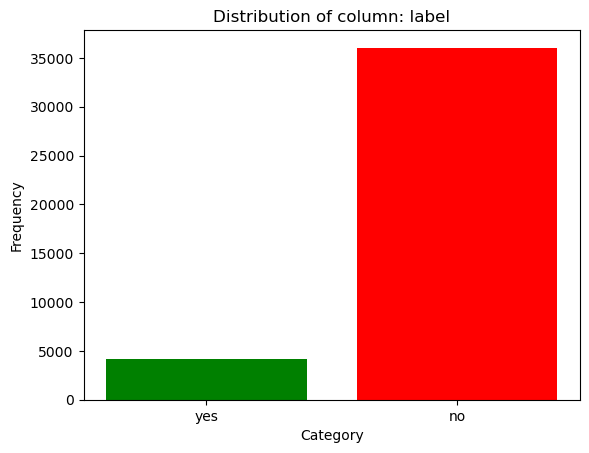

Num of variables with dtype int:  53 
List of names:  ['job=housemaid', 'job=services', 'job=admin.', 'job=blue-collar', 'job=technician', 'job=retired', 'job=management', 'job=unemployed', 'job=self-employed', 'job=unknown', 'job=entrepreneur', 'job=student', 'marital=married', 'marital=single', 'marital=divorced', 'marital=unknown', 'education=basic.4y', 'education=high.school', 'education=basic.6y', 'education=basic.9y', 'education=professional.course', 'education=unknown', 'education=university.degree', 'education=illiterate', 'default=0', 'default=unknown', 'default=1', 'housing=0', 'housing=1', 'housing=unknown', 'loan=0', 'loan=1', 'loan=unknown', 'contact=cellular', 'month=may', 'month=jun', 'month=jul', 'month=aug', 'month=oct', 'month=nov', 'month=dec', 'month=mar', 'month=apr', 'month=sep', 'day_of_week=mon', 'day_of_week=tue', 'day_of_week=wed', 'day_of_week=thu', 'day_of_week=fri', 'poutcome=nonexistent', 'poutcome=failure', 'poutcome=success', 'class'] 

Num of variables 

In [317]:
# How many instances are there in each class, are the classes imbalanced
count_yes = data['class'].value_counts().get(1)
count_no  = data['class'].value_counts().get(0)

# Data set is imbalanced, around 10% of the data set is considered an outlier and 90% an inlier. 
# This means that the data set could be considered an imbalanced data set
print(f"Number of yes instances: ", count_yes,'\n' 'percentage: ', (count_yes/40188) *100.)
print("Number of no instances: ",count_no)
print("Total number of instances: ",count_no+count_yes, '\n')

plt.bar(['yes', 'no'], [count_yes, count_no], color=['green', 'red'])
plt.title('Distribution of column: label')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

# How many variables are in the data? What is the data type and the distribution of each variable
n_of_variables = len(data.columns)

int_cols = data.select_dtypes(include='int64').columns.to_list()
float_cols = data.select_dtypes(include='float64').columns.to_list()

# prints the len and the names of the different columns
print("Num of variables with dtype int: ", len(int_cols), "\nList of names: ",int_cols,"\n")
print("Num of variables with dtype float: ",len(float_cols), "\nList of names: ", float_cols)
   

In [318]:
# selecting only the features that are relevant for description 
desc = data[['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']]

print(desc.describe())


                age      duration      campaign         pdays      previous  \
count  40188.000000  40188.000000  40188.000000  40188.000000  40188.000000   
mean       0.284092      0.051847      0.028610      0.965300      0.024119   
std        0.127940      0.051967      0.050590      0.182451      0.069609   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.185185      0.020740      0.000000      1.000000      0.000000   
50%        0.259259      0.036194      0.018182      1.000000      0.000000   
75%        0.370370      0.064050      0.036364      1.000000      0.000000   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  40188.000000    40188.000000   40188.000000  40188.000000  40188.000000  
mean       0.728616        0.536740       0.430275      0.681292      0.772429  
std        0.325611        0.224757       0.1

62.9609756097561


/var/folders/x_/trxpmpdd6bs561f4gjk661mw0000gn/T/ipykernel_21531/3526795344.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_counts.values, y=job_counts.index, palette="Blues_r")


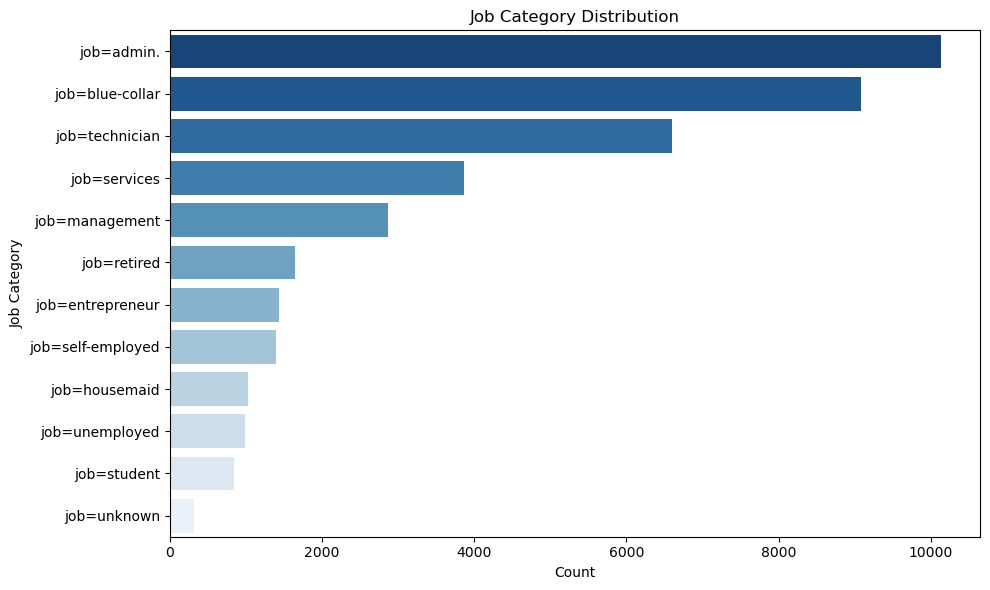

In [319]:
# get all one-hot columns for job
job_cols = [col for col in data.columns if col.startswith("job=")]

# count how often each job category occurs
job_counts = data[job_cols].sum().sort_values(ascending=False)
amount = 0
for i in job_counts[:3]:
    amount += i

print((amount/41000) * 100)
    
plt.figure(figsize=(10, 6))
sns.barplot(x=job_counts.values, y=job_counts.index, palette="Blues_r")
plt.title("Job Category Distribution")
plt.xlabel("Count")
plt.ylabel("Job Category")
plt.tight_layout()
plt.show()

32.91463414634146


/var/folders/x_/trxpmpdd6bs561f4gjk661mw0000gn/T/ipykernel_21531/3108961604.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print((month_cols[0]/41000)*100)
/var/folders/x_/trxpmpdd6bs561f4gjk661mw0000gn/T/ipykernel_21531/3108961604.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.values, y=month_counts.index, palette="Greens_r")


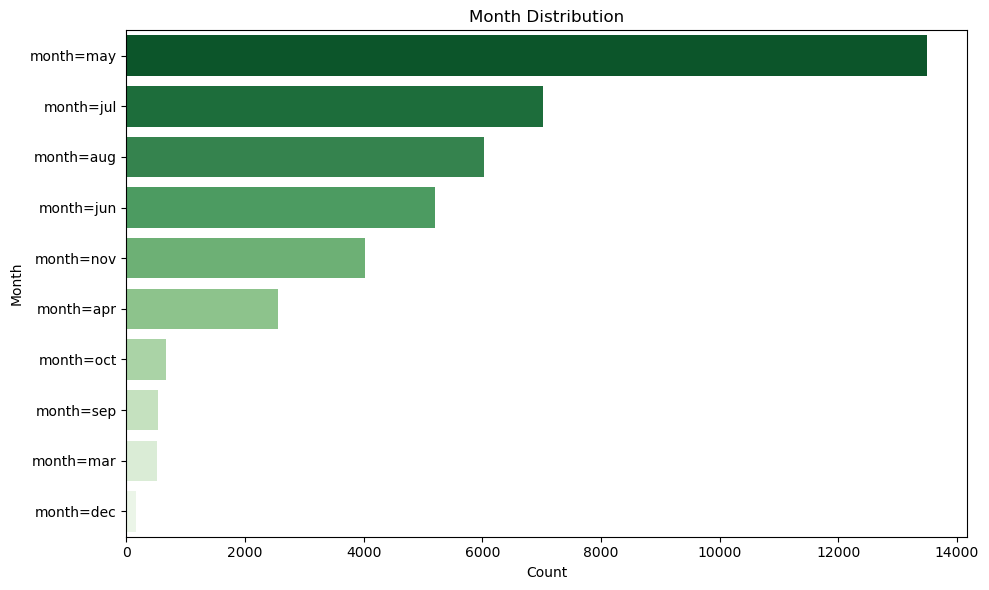

In [320]:
# Get all one-hot columns for month
month_cols = [col for col in data.columns if col.startswith("month=")]

month_counts = data[month_cols].sum().sort_values(ascending=False)

# count how often each job category occurs
month_cols = data[month_cols].sum().sort_values(ascending=False)

print((month_cols[0]/41000)*100)

plt.figure(figsize=(10, 6))
sns.barplot(x=month_counts.values, y=month_counts.index, palette="Greens_r")
plt.title("Month Distribution")
plt.xlabel("Count")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

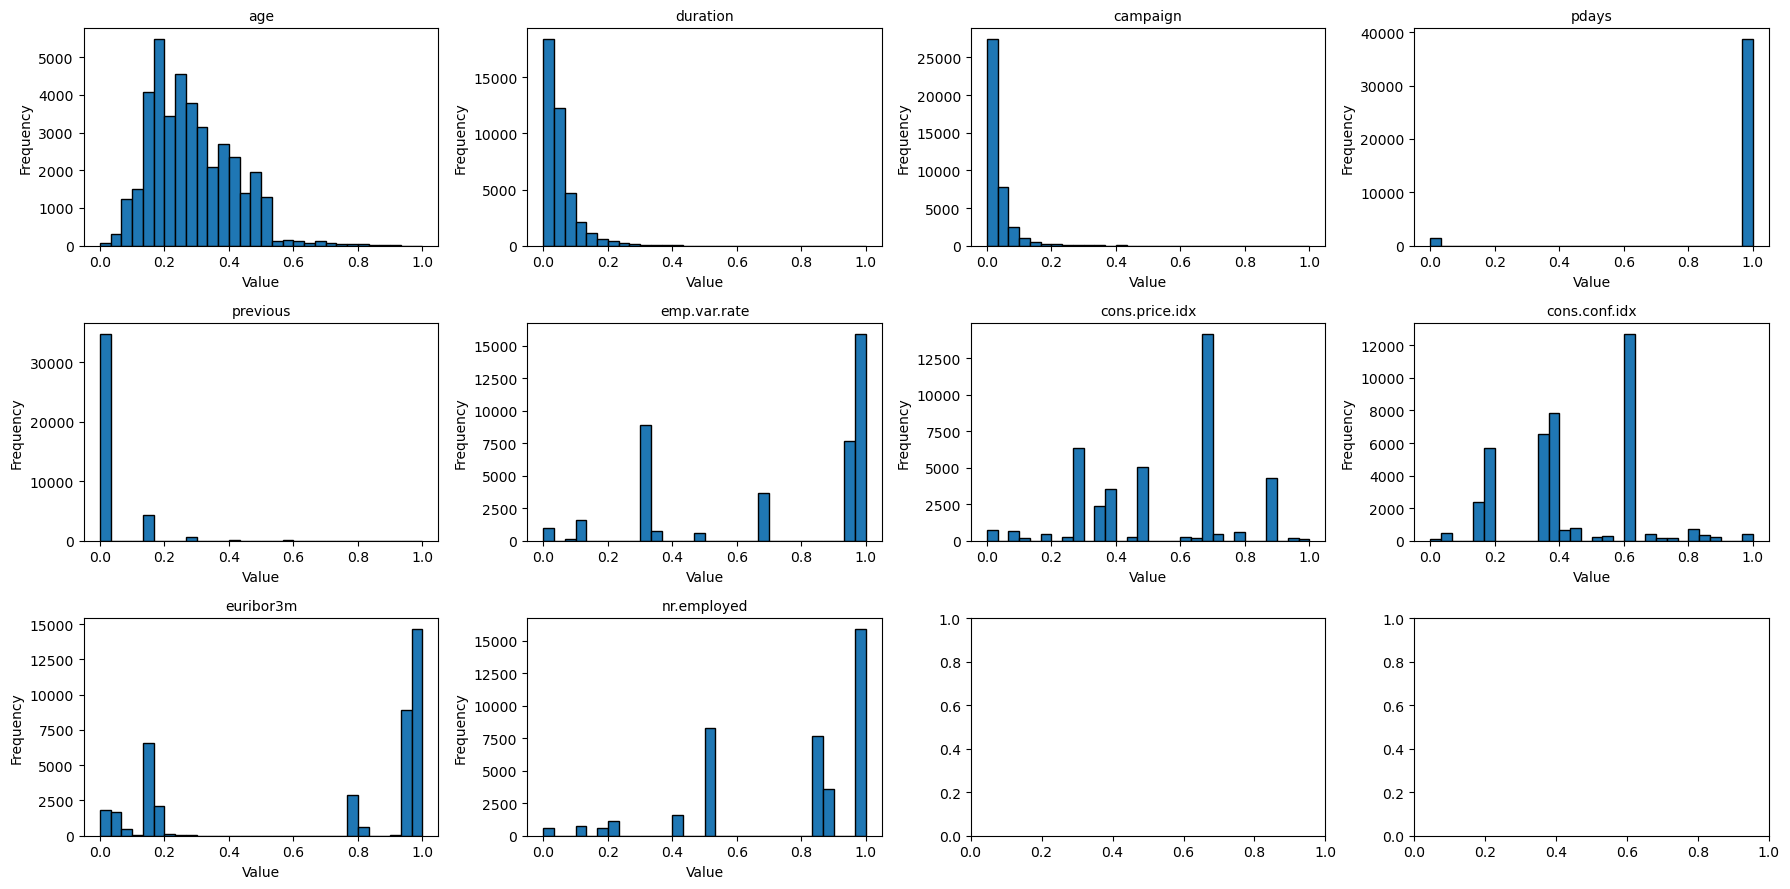

In [321]:
# Number of float variables
num_floats = len(float_cols)
num_rows = math.ceil(num_floats / 4)   

# create grid
fig, axes = plt.subplots(num_rows, 4, figsize=(18, num_rows * 3))
axes = axes.flatten()

# Plot each float histogram
for i, col in enumerate(float_cols):
    axes[i].hist(data[col], bins=30, edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

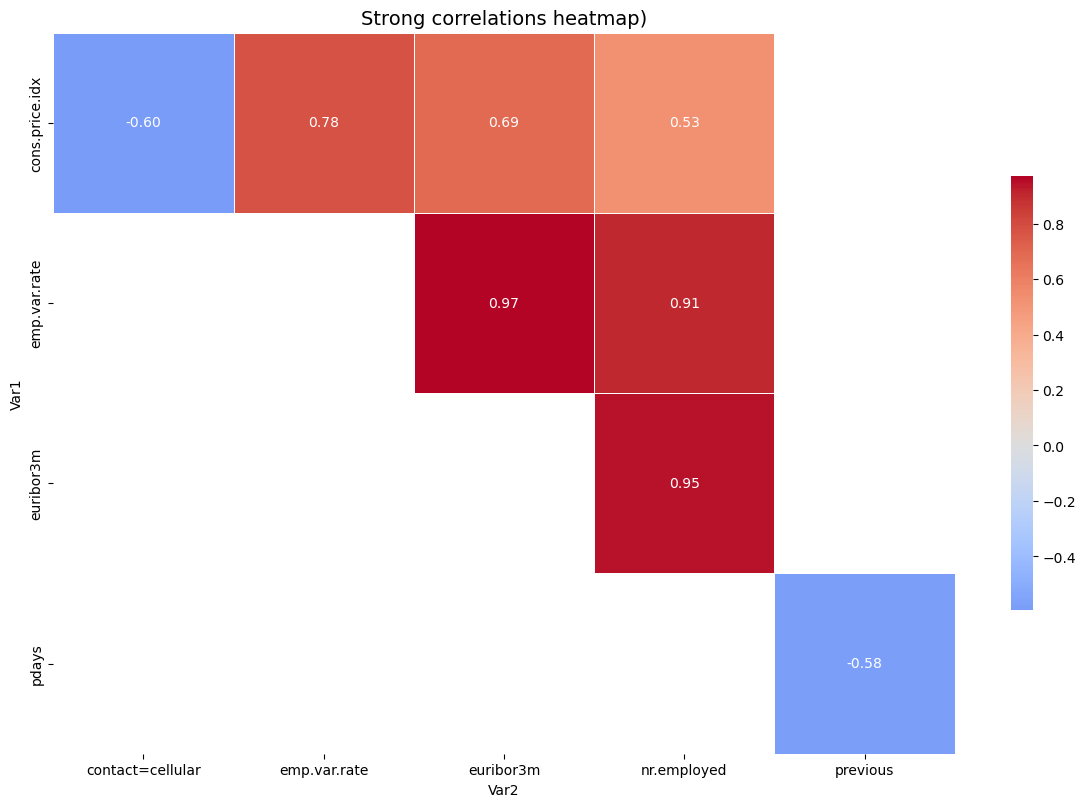

In [322]:
# drop corresponding dummy variables
cols_to_drop = data.filter(regex='marital=|loan=|housing=|poutcome=|default=').columns
data_no_dummies = data.drop(columns=cols_to_drop)

# compute the correlation matrix
corr = data_no_dummies.corr()

# set treshold
threshold = 0.5

# create correlation setup
strong_corr = corr.stack().reset_index()
strong_corr.columns = ['Var1', 'Var2', 'Correlation']

# remove self-correlations and duplicate pairs
strong_corr = strong_corr[(strong_corr['Var1'] < strong_corr['Var2']) &
                          (strong_corr['Correlation'].abs() > threshold)]

# pivot strong_corr into a matrix for heatmap
heatmap_data = strong_corr.pivot(index='Var1', columns='Var2', values='Correlation')

# set up the figure
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(
    heatmap_data,
    annot=True,           
    fmt=".2f",
    cmap="coolwarm",      
    center=0,             
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.6}
)

plt.title("Strong correlations heatmap)", fontsize=14)
plt.tight_layout()
plt.show()

### 1.2. Creating Train and Test data sets

Create a training and a held-out test data set. *Later in Task 2-4, the training data will be used to perform cross-validation. The held-out test data will be used to evaluate the performance of the selected models.*

Choose the size of your test data and motivate your choice when you discuss the experiment setup in your report. 

Tips: 

*You may use the [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) class provided by sklearn*

In [355]:
# import method to make a train/test split
from sklearn.model_selection import train_test_split

# copy data
df = data.copy()

# create X and y
features = ['age', 'job=housemaid', 'job=services', 'job=admin.', 'job=blue-collar',
       'job=technician', 'job=retired', 'job=management', 'job=unemployed',
       'job=self-employed', 'job=unknown', 'job=entrepreneur', 'job=student',
       'marital=married', 'marital=single', 'marital=divorced',
       'marital=unknown', 'education=basic.4y', 'education=high.school',
       'education=basic.6y', 'education=basic.9y',
       'education=professional.course', 'education=unknown',
       'education=university.degree', 'education=illiterate', 'default=0',
       'default=unknown', 'default=1', 'housing=0', 'housing=1',
       'housing=unknown', 'loan=0', 'loan=1', 'loan=unknown',
       'contact=cellular', 'month=may', 'month=jun', 'month=jul', 'month=aug',
       'month=oct', 'month=nov', 'month=dec', 'month=mar', 'month=apr',
       'month=sep', 'day_of_week=mon', 'day_of_week=tue', 'day_of_week=wed',
       'day_of_week=thu', 'day_of_week=fri', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome=nonexistent', 'poutcome=failure',
       'poutcome=success', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed']

X = df[features]
y = df[['class']]

X = X[0:14000]
y = y[0:14000]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y,test_size=0.2)

## Task 2: Decision Trees 
### - Outlier Detection as a Supervised Classification

### 2.1 Training a Decision Tree

Use the basic [Decision Tree](http://scikit-learn.org/stable/modules/tree.html#tree) library in sklearn to learn a decision tree model by fitting the full training data.

Show/plot the tree diagram and also plot the feature importances. 
What do you observe?


#### Tips:

To show the tree diagram, you may use the graphviz library or use the plot_tree function, see https://scikit-learn.org/stable/modules/tree.html




Feature: age, Score: 0.07679393428666961
Feature: duration, Score: 0.3389655745929379
Feature: euribor3m, Score: 0.06502217437764969
Feature: nr.employed, Score: 0.15049190677857693


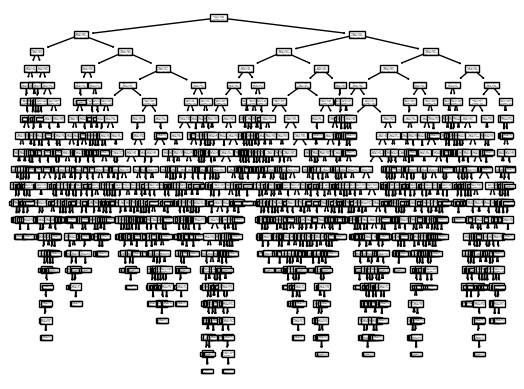

In [324]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

cl = tree.DecisionTreeClassifier()
cl.fit(X_train, y_train)

tree.plot_tree(cl)

importance = cl.feature_importances_

# find corresponding feature names for accuracy > 0.05
for i, v in enumerate(importance):  
    if v > 0.05:
        print(f'Feature: {features[i]}, Score: {v}')


### 2.2 Confusion Matrix and Accuracy

Compute the *confusion matrix* and *accuracy* of the tree using the held-out data set. Moreover, also compute the *recall*, *precision*, and *F1-score* of the tree. 


For this part, you can either implement your own functions or use the following scikit-learn libraries.  
- [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix)
- [accuracy score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
- [recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score)
- [precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score)
- [f1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score)
- [classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html#sklearn.metrics.classification_report)


Reflect on the performance of the model and be aware of the difference between *accuracy* and *F1-score*. How good is this decision tree model for outlier detection?

In [325]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred = cl.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Evaluation Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\n=== Confusion Matrix ===")
print(conf_matrix)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Evaluation Metrics ===
Accuracy : 0.8939
Precision: 0.4965
Recall   : 0.4746
F1-score : 0.4853

=== Confusion Matrix ===
[[2363  142]
 [ 155  140]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2505
           1       0.50      0.47      0.49       295

    accuracy                           0.89      2800
   macro avg       0.72      0.71      0.71      2800
weighted avg       0.89      0.89      0.89      2800



### 2.3 Features to Tree  (optional)

Use the training data to re-fit a new decision tree with the parameter max_depth set to 4. Show the tree diagram and also plot the feature importances. 

Recalculate the performance of this simpler model. 

What do you observe?


=== Evaluation Metrics ===
Accuracy : 0.9125
Precision: 0.6359
Recall   : 0.3966
F1-score : 0.4885

=== Confusion Matrix ===
[[2438   67]
 [ 178  117]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      2505
           1       0.64      0.40      0.49       295

    accuracy                           0.91      2800
   macro avg       0.78      0.68      0.72      2800
weighted avg       0.90      0.91      0.90      2800



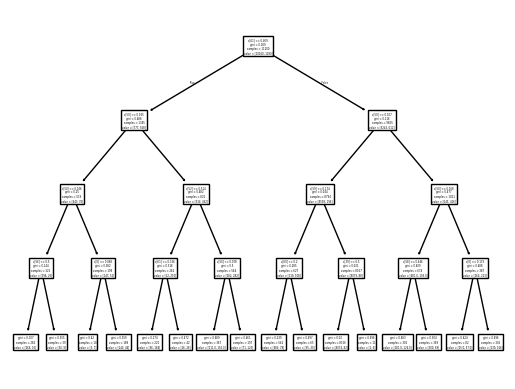

In [326]:

cl = tree.DecisionTreeClassifier(max_depth=4)
cl.fit(X_train, y_train)

tree.plot_tree(cl)

y_pred = cl.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Evaluation Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\n=== Confusion Matrix ===")
print(conf_matrix)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


### 2.4 Cross validation (optional)

The code example shown here below uses the [kfold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold) method to implement 5-fold cross-validation. Moreover, it uses the cross validation to explore how the max_depth influences the model performance. It keeps track of the validation accuracy scores and F1-scores across the 5 folds. 


Now, change the code to also compute the recall and precision. 


In [327]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# create 5-fold cross-validation
nk = 5
kf = KFold(n_splits=nk, random_state=0, shuffle=True)

# Search the parameter among the following
C = np.arange(2, 10)

# init metrics: rows = folds, cols = different max_depths
acc = np.zeros((nk, len(C)))
f1  = np.zeros((nk, len(C)))
prec = np.zeros((nk, len(C)))
rec = np.zeros((nk, len(C)))

i = 0
for train_index, val_index in kf.split(X_train):
    X_t, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_t, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    j = 0
    for c in C:
        dt = tree.DecisionTreeClassifier(min_samples_leaf=1, max_depth=c)
        dt.fit(X_t, y_t)
        yhat = dt.predict(X_val)

        acc[i][j]  = accuracy_score(y_val, yhat)
        f1[i][j]   = f1_score(y_val, yhat)
        prec[i][j] = precision_score(y_val, yhat)
        rec[i][j]  = recall_score(y_val, yhat)

        j += 1
    i += 1

# Print the results
print("=== Mean Accuracy per max_depth ===")
print(np.mean(acc, axis=0))
print("Selected model index:", np.argmax(np.mean(acc, axis=0)))

print("\n=== Mean F1 per max_depth ===")
print(np.mean(f1, axis=0))
print("Selected model index:", np.argmax(np.mean(f1, axis=0)))

print("\n=== Mean Precision per max_depth ===")
print(np.mean(prec, axis=0))
print("Selected model index:", np.argmax(np.mean(prec, axis=0)))

print("\n=== Mean Recall per max_depth ===")
print(np.mean(rec, axis=0))
print("Selected model index:", np.argmax(np.mean(rec, axis=0)))


=== Mean Accuracy per max_depth ===
[0.90723214 0.9125     0.91508929 0.91116071 0.91348214 0.91116071
 0.91035714 0.90669643]
Selected model index: 2

=== Mean F1 per max_depth ===
[0.47713606 0.53307336 0.55272732 0.51929543 0.56232577 0.54585107
 0.55078271 0.52679361]
Selected model index: 4

=== Mean Precision per max_depth ===
[0.58897563 0.62168677 0.62084108 0.61328515 0.60697022 0.5919881
 0.58219568 0.56813818]
Selected model index: 1

=== Mean Recall per max_depth ===
[0.40257972 0.48975773 0.50419549 0.46195238 0.52617839 0.51082023
 0.52360619 0.49826771]
Selected model index: 4


### 2.5 Tree Tuning



The built-in decision tree algorithm you are using has several parameters which you can tune (e.g., *max_depth* and *min_samples_leaf*). Use 5-fold cross-validation (e.g., reuse the code of task 2.4 and adapt the code for two parameters), show how the choice of these parameters affects performance. 


#### Tips: 
Make a decision on the range of values that you would try for the two parameters and discuss your choice in the experiment setup section.

Here is a guide that helps you to build the experiment.
First, reuse the code of task 2.4 and show how max_depth affects train and **validation accuracy**. On a single axis, plot train and **validation accuracy** as a function of max_depth. Use a red line to show validation accuracy and a blue line to show train accuracy. (Do not use your (held-out) **test data** yet). 

Second, show how validation accuracy relates to both max_depth and min_samples_leaf. Specifically, create a 3-D plot where the x-axis is max_depth, the y-axis is min_samples_leaf, and the z-axis shows accuracy. What combination of max_depth and min-samples_leaf achieves the highest F1 score? How sensitive are the results to these two parameters? 

Finally, select the best-performing decision tree (i.e., the one that achieved the highest cross-validated performance) and report the performance of the fitted model on the held-out test data -- how does it compare to the cross-validated F1 score?


Depths: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Mean train accuracy: [0.90912946 0.91495536 0.92011161 0.92486607 0.93033482 0.93756696
 0.94486607 0.95323661 0.96136161 0.96877232 0.97680804 0.98341518
 0.98832589 0.99232143 0.995625   0.99761161 0.99886161 0.99955357
 0.99988839]
Mean val accuracy: [0.90723214 0.9125     0.91508929 0.91098214 0.91321429 0.91160714
 0.90973214 0.90598214 0.90401786 0.89892857 0.89892857 0.89696429
 0.89848214 0.89571429 0.894375   0.89258929 0.89133929 0.89303571
 0.89205357]


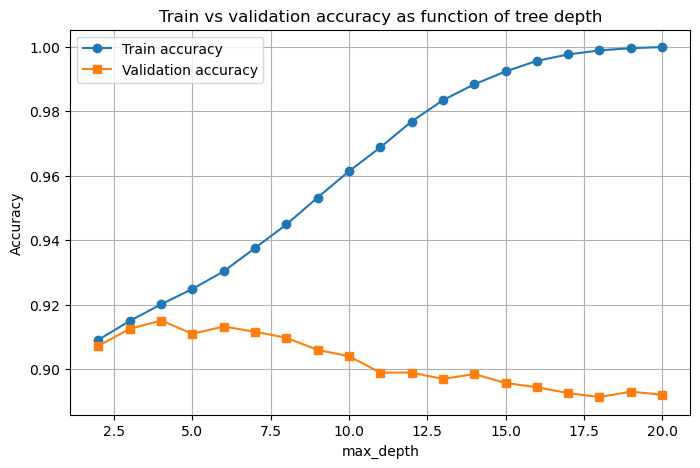

In [328]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt



nk = 5
kf = KFold(n_splits=nk, random_state=0, shuffle=True)

depth_values = range(2, 21)  

train_acc = np.zeros((nk, len(depth_values)))
val_acc   = np.zeros((nk, len(depth_values)))

for i, (train_index, val_index) in enumerate(kf.split(X_train)):
    X_t, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_t, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    for j, d in enumerate(depth_values):
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=1, random_state=0)
        dt.fit(X_t, y_t)

        # accuracy on the fold's train and validation splits
        yhat_train = dt.predict(X_t)
        yhat_val   = dt.predict(X_val)

        train_acc[i, j] = accuracy_score(y_t, yhat_train)
        val_acc[i, j]   = accuracy_score(y_val, yhat_val)

# mean accuracy over folds
mean_train_acc = train_acc.mean(axis=0)
mean_val_acc   = val_acc.mean(axis=0)

print("Depths:", list(depth_values))
print("Mean train accuracy:", mean_train_acc)
print("Mean val accuracy:", mean_val_acc)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(depth_values, mean_train_acc, label="Train accuracy", linestyle="-", marker="o")
plt.plot(depth_values, mean_val_acc,   label="Validation accuracy", linestyle="-", marker="s")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs validation accuracy as function of tree depth")
plt.legend()
plt.grid(True)
plt.show()

In [329]:
from mpl_toolkits.mplot3d import Axes3D 
from sklearn.metrics import f1_score

depth_values = [2, 4, 6, 8, 10, 12]
leaf_values  = [1, 5, 10, 20, 50]

nk = 5
kf = KFold(n_splits=nk, random_state=0, shuffle=True)

acc_grid = np.zeros((len(depth_values), len(leaf_values)))
f1_grid  = np.zeros((len(depth_values), len(leaf_values)))
prec_grid = np.zeros((len(depth_values), len(leaf_values)))
rec_grid = np.zeros((len(depth_values), len(leaf_values)))

for di, d in enumerate(depth_values):
    for li, leaf in enumerate(leaf_values):

        fold_acc = []
        fold_f1  = []
        fold_prec = []
        fold_rec = []

        for train_index, val_index in kf.split(X_train):
            X_t, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
            y_t, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

            dt = DecisionTreeClassifier(max_depth=d,
                                        min_samples_leaf=leaf,
                                        random_state=0)
            dt.fit(X_t, y_t)
            yhat_val = dt.predict(X_val)

            fold_acc.append(accuracy_score(y_val, yhat_val))
            fold_f1.append(f1_score(y_val, yhat_val))
            fold_prec.append(precision_score(y_val, yhat_val))
            fold_rec.append(recall_score(y_val, yhat_val))

        acc_grid[di, li] = np.mean(fold_acc)
        f1_grid[di, li]  = np.mean(fold_f1)
        prec_grid[di, li] = np.mean(fold_prec)
        rec_grid[di, li] = np.mean(fold_rec)

print("Validation accuracy grid:\n", acc_grid)
print("Validation F1 grid:\n", f1_grid)

Validation accuracy grid:
 [[0.90723214 0.90723214 0.90723214 0.90723214 0.90723214]
 [0.91508929 0.91508929 0.91526786 0.91535714 0.915625  ]
 [0.91321429 0.91339286 0.91267857 0.91482143 0.91392857]
 [0.90973214 0.90955357 0.90928571 0.91348214 0.91410714]
 [0.90401786 0.90678571 0.9075     0.91330357 0.91410714]
 [0.89892857 0.90258929 0.90803571 0.91339286 0.91410714]]
Validation F1 grid:
 [[0.47713606 0.47713606 0.47713606 0.47713606 0.47713606]
 [0.55272732 0.55272732 0.55379412 0.55406367 0.54987262]
 [0.56116572 0.55182431 0.55539007 0.55786461 0.53408275]
 [0.55211688 0.53884974 0.53174425 0.53783053 0.53654649]
 [0.52111068 0.53055675 0.51542365 0.53101043 0.53654649]
 [0.49807164 0.50624922 0.50993407 0.52871001 0.53654649]]


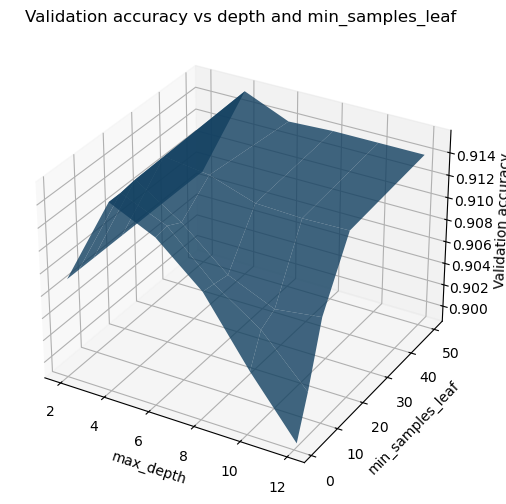

In [330]:
D, L = np.meshgrid(depth_values, leaf_values, indexing="ij") 

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(D, L, acc_grid, alpha=0.8)
ax.set_xlabel("max_depth")
ax.set_ylabel("min_samples_leaf")
ax.set_zlabel("Validation accuracy")
ax.set_title("Validation accuracy vs depth and min_samples_leaf")
plt.show()

In [331]:
best_index = np.unravel_index(np.argmax(f1_grid), f1_grid.shape)
best_depth = depth_values[best_index[0]]
best_leaf  = leaf_values[best_index[1]]
best_f1_cv = f1_grid[best_index]

print("Best hyperparameters by F1:")
print("  max_depth =", best_depth)
print("  min_samples_leaf =", best_leaf)
print("  mean cross-validated F1 =", best_f1_cv)

dt_validation_acc = acc_grid[best_index]
dt_validation_f1 = f1_grid[best_index]  
dt_validation_precision = prec_grid[best_index]
dt_validation_recall = rec_grid[best_index]

print("\nDecision Tree Best Validation Result:")
print(f"Accuracy : {dt_validation_acc:.4f}")
print(f"Precision: {dt_validation_precision:.4f}")
print(f"Recall   : {dt_validation_recall:.4f}")
print(f"F1-score : {dt_validation_f1:.4f}")

dt_validation_results = {
    "accuracy": dt_validation_acc,
    "precision": dt_validation_precision,
    "recall": dt_validation_recall,
    "f1": dt_validation_f1
}


Best hyperparameters by F1:
  max_depth = 6
  min_samples_leaf = 1
  mean cross-validated F1 = 0.5611657247690214

Decision Tree Best Validation Result:
Accuracy : 0.9132
Precision: 0.6055
Recall   : 0.5254
F1-score : 0.5612


In [332]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Train final model with best hyperparameters on all training data
final_dt = DecisionTreeClassifier(max_depth=best_depth,
                                  min_samples_leaf=best_leaf,
                                  random_state=0)
final_dt.fit(X_train, y_train)

# Evaluate on held-out test set
y_test_pred = final_dt.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Held-out test performance:")
print("  Accuracy :", test_acc)
print("  Precision:", test_prec)
print("  Recall   :", test_rec)
print("  F1-score :", test_f1)
dt_test_results = {
    "accuracy": test_acc,
    "precision": test_prec,
    "recall": test_rec,
    "f1": test_f1
}

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred))

Held-out test performance:
  Accuracy : 0.9096428571428572
  Precision: 0.5889830508474576
  Recall   : 0.4711864406779661
  F1-score : 0.5235404896421846

Confusion matrix:
[[2408   97]
 [ 156  139]]

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2505
           1       0.59      0.47      0.52       295

    accuracy                           0.91      2800
   macro avg       0.76      0.72      0.74      2800
weighted avg       0.90      0.91      0.91      2800



## Task 3. Random Forest
### - Outlier Detection as a Supervised Classification

Now use a [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) to predict the labels for the data set. 

i) use the default values for the parameters to get a RF model running. 

ii) use 5-fold cross-validation to determine a possibly better choice for the parameter *n_estimators* and *max_features*
    
iii) select the best-performing decision tree (i.e., the one that achieved the highest cross-validated performance) and report the performance of the fitted model on the held-out test data ?

In the report, reflect on how does the test performance of RF compare to the decision tree performance? 
 



In [333]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

# Random Forest using default values
rf_default = RandomForestClassifier(random_state=42) 
rf_default.fit(X_train, y_train.values.ravel())
y_pred_default = rf_default.predict(X_test)

default_test_acc = accuracy_score(y_test, y_pred_default)
default_test_prec = precision_score(y_test, y_pred_default)
default_test_rec = recall_score(y_test, y_pred_default)
default_test_f1 = f1_score(y_test, y_pred_default)

print("\nDefault RF Evaluation Metrics:")
print("Accuracy:", default_test_acc)
print(f"Precision: {default_test_prec:.4f}")
print(f"Recall   : {default_test_rec:.4f}")
print(f"F1-score : {default_test_f1:.4f}")

# we use a smaller subset for hyperparameter tuning to reduce computation time
sample_size = 2000
indices = np.random.RandomState(42).choice(len(X_train), min(sample_size, len(X_train)), replace=False)
X_train_sample = X_train.iloc[indices]
y_train_sample = y_train.iloc[indices]

# Hyperparameter grid
n_estimators_values = [250, 500, 750]
max_features_values = ["sqrt", "log2", None]

# 5-fold cross-validation on sample
nk = 5
kf = KFold(n_splits=nk, random_state=0, shuffle=True)

acc_grid = np.zeros((len(n_estimators_values), len(max_features_values)))
f1_grid = np.zeros((len(n_estimators_values), len(max_features_values)))
prec_grid = np.zeros((len(n_estimators_values), len(max_features_values)))
rec_grid = np.zeros((len(n_estimators_values), len(max_features_values)))

for ni, n_est in enumerate(n_estimators_values):
    for fi, max_feat in enumerate(max_features_values):
        
        fold_acc = []
        fold_f1 = []
        fold_prec = []
        fold_rec = []
        
        print(f"Testing n_estimators={n_est}, max_features={max_feat}")
        
        for train_index, val_index in kf.split(X_train_sample):
            X_t, X_val = X_train_sample.iloc[train_index], X_train_sample.iloc[val_index]
            y_t, y_val = y_train_sample.iloc[train_index], y_train_sample.iloc[val_index]
            
            rf = RandomForestClassifier(
                n_estimators=n_est,
                max_features=max_feat,
                random_state=42
            )
            rf.fit(X_t, y_t.values.ravel())
            yhat_val = rf.predict(X_val)
            
            fold_acc.append(accuracy_score(y_val, yhat_val))
            fold_f1.append(f1_score(y_val, yhat_val))
            fold_prec.append(precision_score(y_val, yhat_val))
            fold_rec.append(recall_score(y_val, yhat_val))
        
        acc_grid[ni, fi] = np.mean(fold_acc)
        f1_grid[ni, fi] = np.mean(fold_f1)
        prec_grid[ni, fi] = np.mean(fold_prec)
        rec_grid[ni, fi] = np.mean(fold_rec)

# Find best parameters by F1 score
best_index = np.unravel_index(np.argmax(f1_grid), f1_grid.shape)
best_n_estimators = n_estimators_values[best_index[0]]
best_max_features = max_features_values[best_index[1]]

print("\n" + "="*50)
print("Random Forest Hyperparameter Tuning Results (on sample)")
print(f"Best n_estimators: {best_n_estimators}")
print(f"Best max_features: {best_max_features}")
print(f"Best CV F1 score on sample: {f1_grid[best_index]:.4f}")

# we rerun a 5-fold CV on the FULL training set to give us the final validation results
print("\n" + "="*50)
print("Re-running 5-fold CV on FULL training set with best hyperparameters...")

acc_full = []
f1_full = []
prec_full = []
rec_full = []

for train_index, val_index in kf.split(X_train):
    X_t, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_t, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    rf = RandomForestClassifier(
        n_estimators=best_n_estimators,
        max_features=best_max_features,
        random_state=42
    )
    rf.fit(X_t, y_t.values.ravel())
    yhat_val = rf.predict(X_val)
    
    acc_full.append(accuracy_score(y_val, yhat_val))
    f1_full.append(f1_score(y_val, yhat_val))
    prec_full.append(precision_score(y_val, yhat_val))
    rec_full.append(recall_score(y_val, yhat_val))

rf_validation_acc = np.mean(acc_full)
rf_validation_f1 = np.mean(f1_full)
rf_validation_precision = np.mean(prec_full)
rf_validation_recall = np.mean(rec_full)

print("\nRandom Forest Best Validation Result (full training set):")
print(f"Accuracy : {rf_validation_acc:.4f}")
print(f"Precision: {rf_validation_precision:.4f}")
print(f"Recall   : {rf_validation_recall:.4f}")
print(f"F1-score : {rf_validation_f1:.4f}")

rf_validation_results = {
    "accuracy": rf_validation_acc,
    "precision": rf_validation_precision,
    "recall": rf_validation_recall,
    "f1": rf_validation_f1
}

# we train final model on all training data and evaluate on held-out test set
print("\n" + "="*50)
print("Training final model on ALL training data...")

final_rf = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_features=best_max_features,
    random_state=42
)
final_rf.fit(X_train, y_train.values.ravel())
y_test_pred_rf = final_rf.predict(X_test)

test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
test_prec_rf = precision_score(y_test, y_test_pred_rf)
test_rec_rf = recall_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf)

print("\nHeld-out test performance Random Forest:")
print("Accuracy :", test_acc_rf)
print("Precision:", test_prec_rf)
print("Recall   :", test_rec_rf)
print("F1-score :", test_f1_rf)

rf_test_results = {
    "accuracy": test_acc_rf,
    "precision": test_prec_rf,
    "recall": test_rec_rf,
    "f1": test_f1_rf
}


Default RF Evaluation Metrics:
Accuracy: 0.9085714285714286
Precision: 0.6242
Recall   : 0.3322
F1-score : 0.4336
Testing n_estimators=250, max_features=sqrt
Testing n_estimators=250, max_features=log2
Testing n_estimators=250, max_features=None
Testing n_estimators=500, max_features=sqrt
Testing n_estimators=500, max_features=log2
Testing n_estimators=500, max_features=None
Testing n_estimators=750, max_features=sqrt
Testing n_estimators=750, max_features=log2
Testing n_estimators=750, max_features=None

Random Forest Hyperparameter Tuning Results (on sample)
Best n_estimators: 500
Best max_features: None
Best CV F1 score on sample: 0.5776

Re-running 5-fold CV on FULL training set with best hyperparameters...

Random Forest Best Validation Result (full training set):
Accuracy : 0.9157
Precision: 0.6226
Recall   : 0.5139
F1-score : 0.5615

Training final model on ALL training data...

Held-out test performance Random Forest:
Accuracy : 0.9132142857142858
Precision: 0.6160714285714286

## Task 4. Isolation Forest

### 4.1 Apply Isolation Forest
### - Outlier Detection as an Unsupervised Classification

Use the [Isolation Forest Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html) to detect potential outliers in the data set. 

Select two parameters that you would like to investigate (for example, contamination, max_depth, n_estimators, max_samples). For each configuration: 

i) Apply Isolation Forest on the full data set (without using the labels Y)


ii) Use the labels to compute the accuracy, recall, precision, and F1-score on the full data set (using the labels). 


Compare the performance of Isolation Forest of different configurations. 


#### Tips:

- Note that the fit(X) function of the Isolation Forest does not use the labels. 


- **Look carefully at the values that an Isolation Forest classifier returns. Which value represents the outlier class? Be aware that you need to implement a mapping function f(x) that remaps -1 to 1 and 1 to 0, in order to transform the predictions such that the semantics are consistant with the previous classification algorithms.**


- Create 2D (or 3D) plots to visualize your results



Config: {'contamination': 0.05, 'n_estimators': 50}

Accuracy:  0.8956
Precision: 0.4858
Recall:    0.2357
F1-score:  0.3174


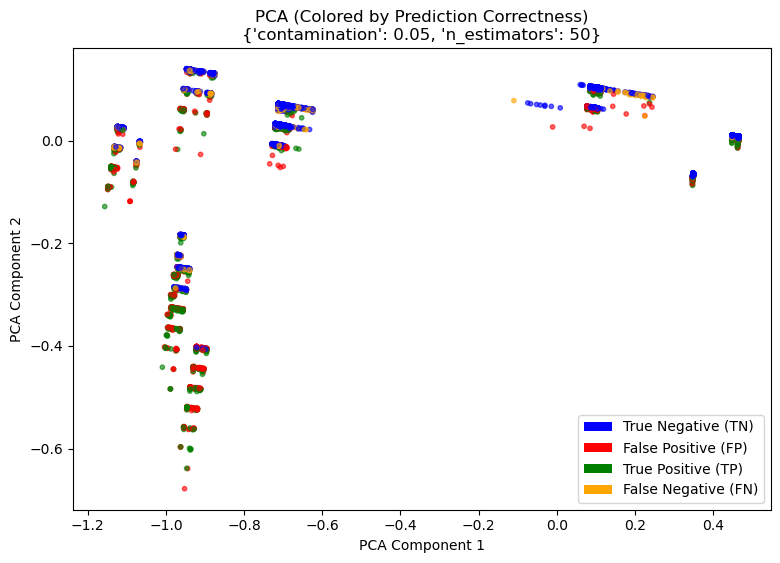

Config: {'contamination': 0.1, 'n_estimators': 50}

Accuracy:  0.8781
Precision: 0.4058
Recall:    0.3940
F1-score:  0.3998


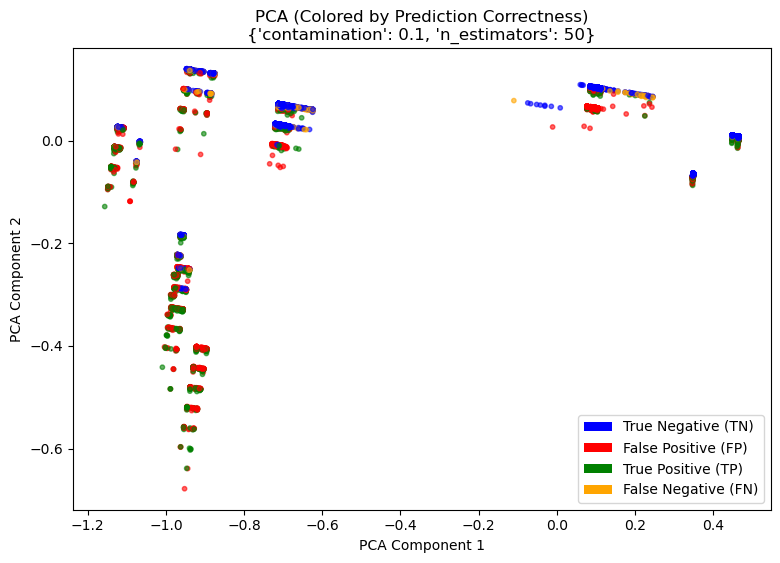

Config: {'contamination': 0.15, 'n_estimators': 50}

Accuracy:  0.8641
Precision: 0.3902
Recall:    0.5679
F1-score:  0.4626


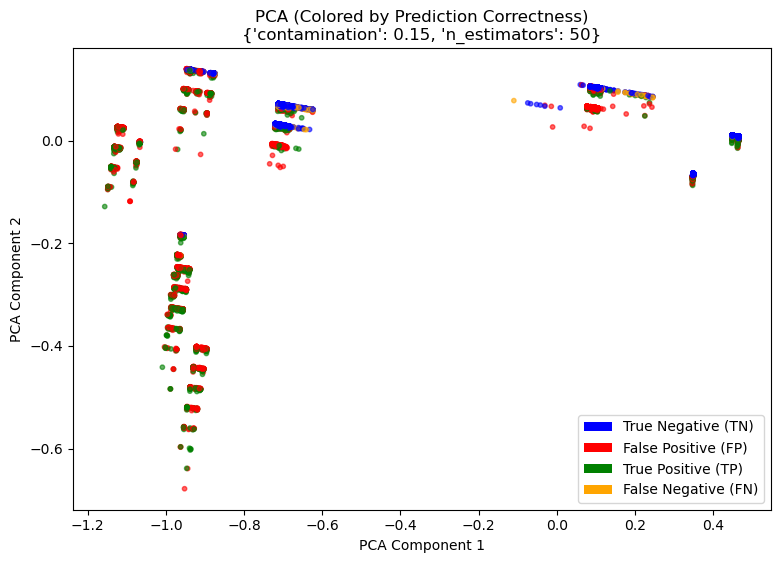

Config: {'contamination': 0.2, 'n_estimators': 50}

Accuracy:  0.8347
Precision: 0.3443
Recall:    0.6684
F1-score:  0.4545


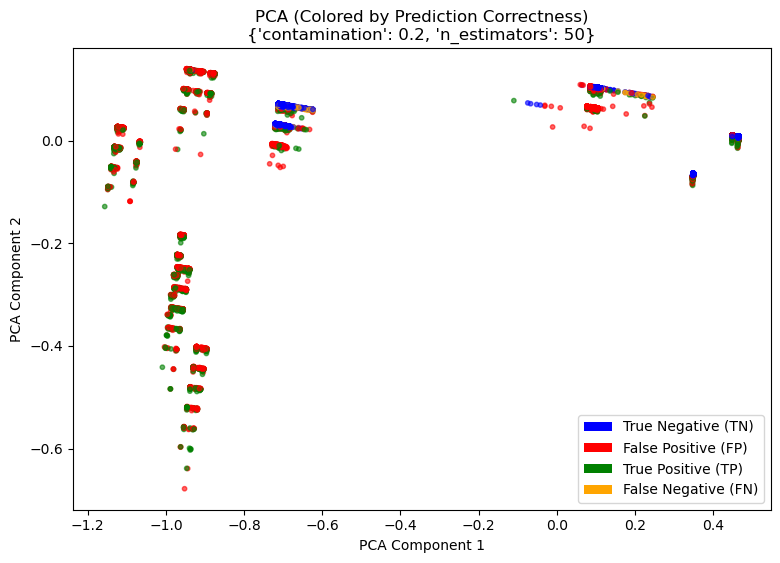

Config: {'contamination': 0.25, 'n_estimators': 50}

Accuracy:  0.7935
Precision: 0.2930
Recall:    0.7106
F1-score:  0.4149


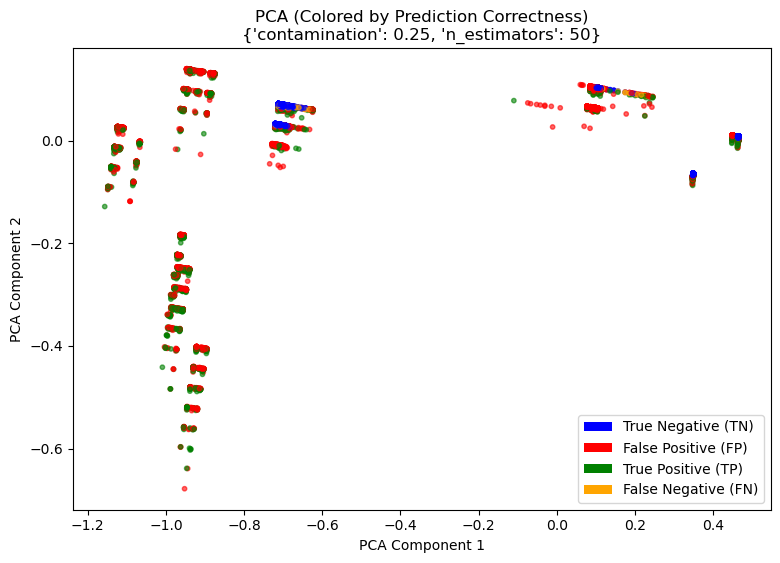

Config: {'contamination': 0.05, 'n_estimators': 100}

Accuracy:  0.8973
Precision: 0.5030
Recall:    0.2442
F1-score:  0.3288


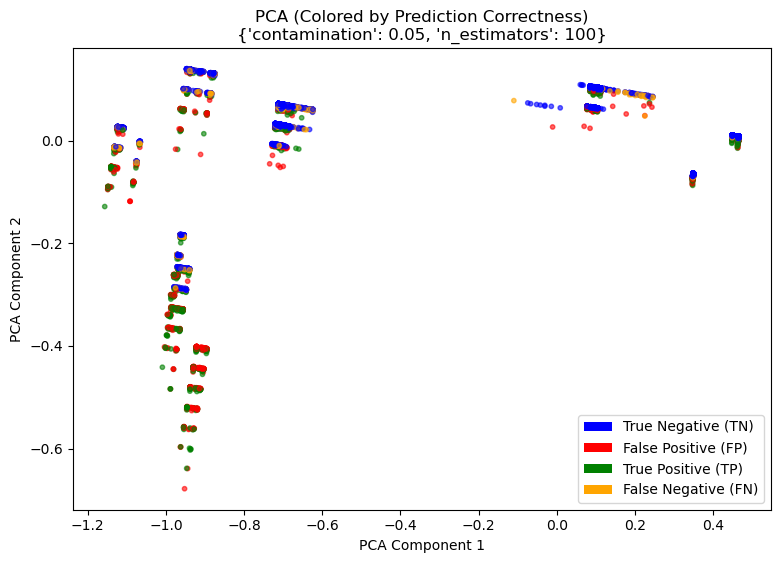

Config: {'contamination': 0.1, 'n_estimators': 100}

Accuracy:  0.8761
Precision: 0.3956
Recall:    0.3841
F1-score:  0.3898


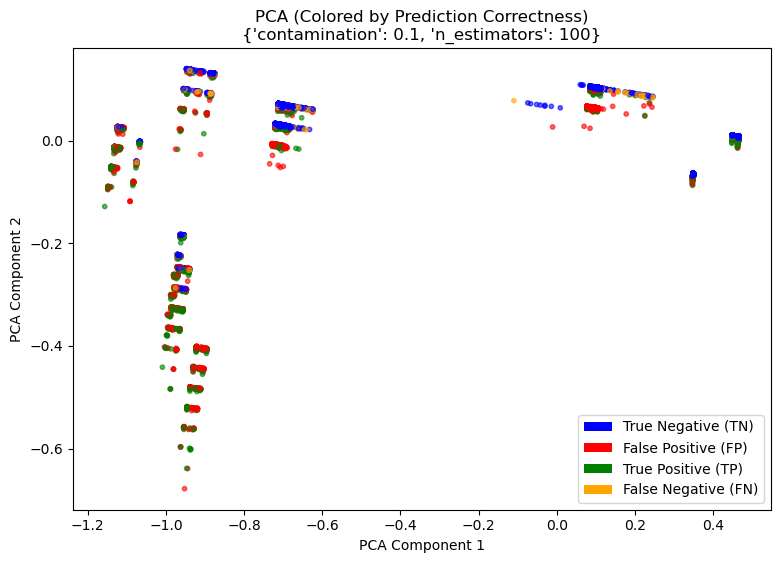

Config: {'contamination': 0.15, 'n_estimators': 100}

Accuracy:  0.8641
Precision: 0.3905
Recall:    0.5686
F1-score:  0.4630


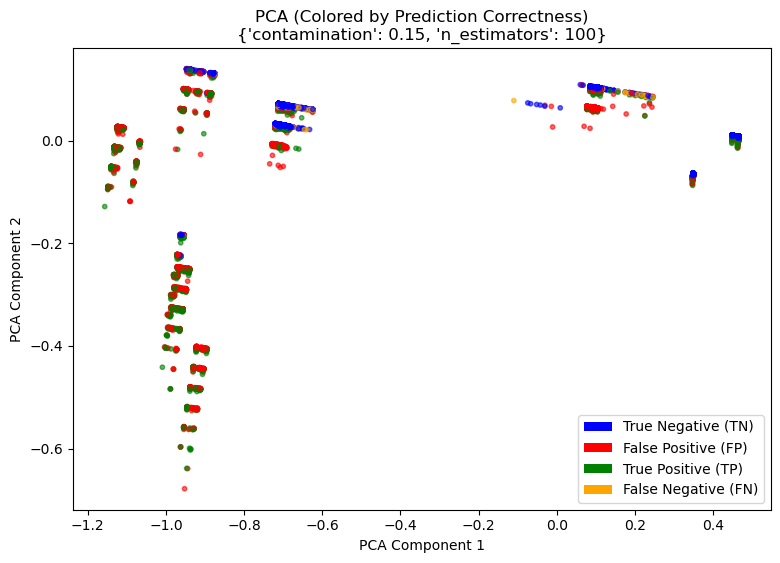

Config: {'contamination': 0.2, 'n_estimators': 100}

Accuracy:  0.8378
Precision: 0.3521
Recall:    0.6836
F1-score:  0.4648


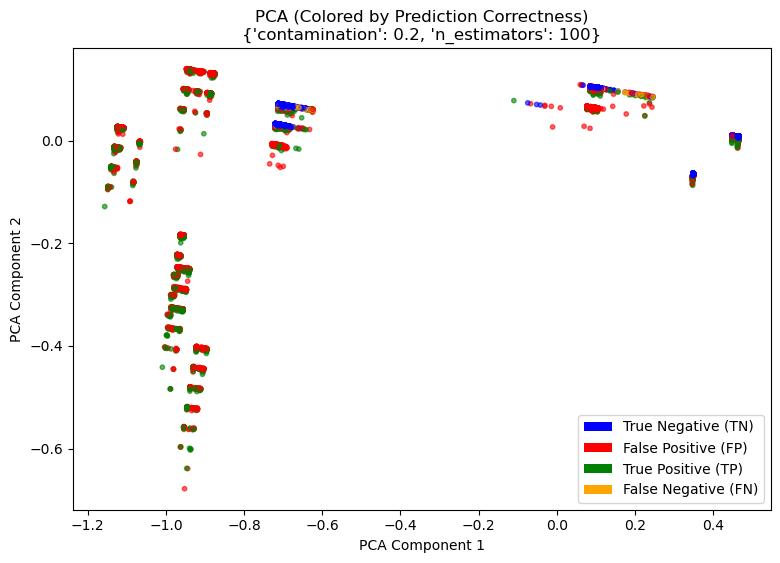

Config: {'contamination': 0.25, 'n_estimators': 100}

Accuracy:  0.7979
Precision: 0.3019
Recall:    0.7326
F1-score:  0.4276


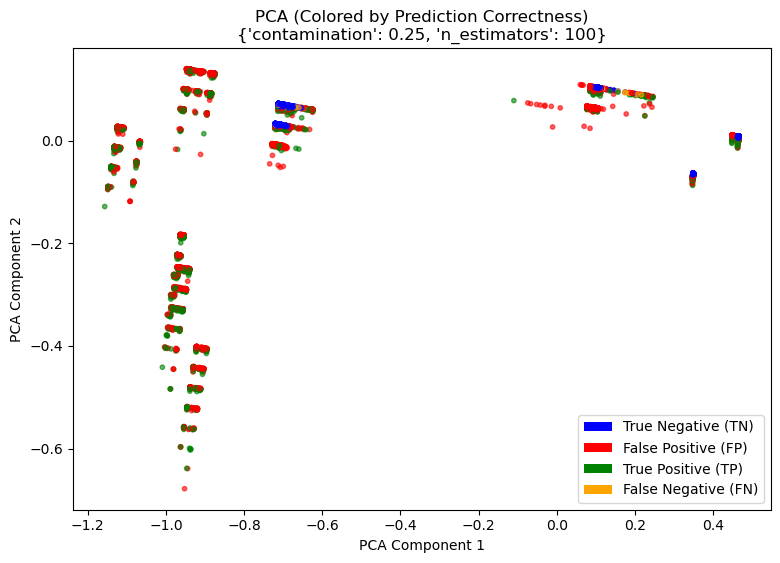

Config: {'contamination': 0.05, 'n_estimators': 150}

Accuracy:  0.8965
Precision: 0.4955
Recall:    0.2406
F1-score:  0.3239


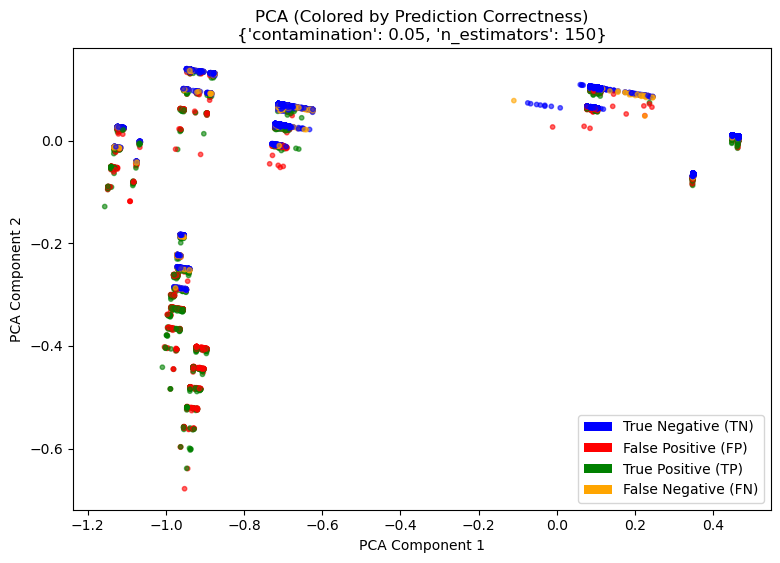

Config: {'contamination': 0.1, 'n_estimators': 150}

Accuracy:  0.8768
Precision: 0.3991
Recall:    0.3874
F1-score:  0.3932


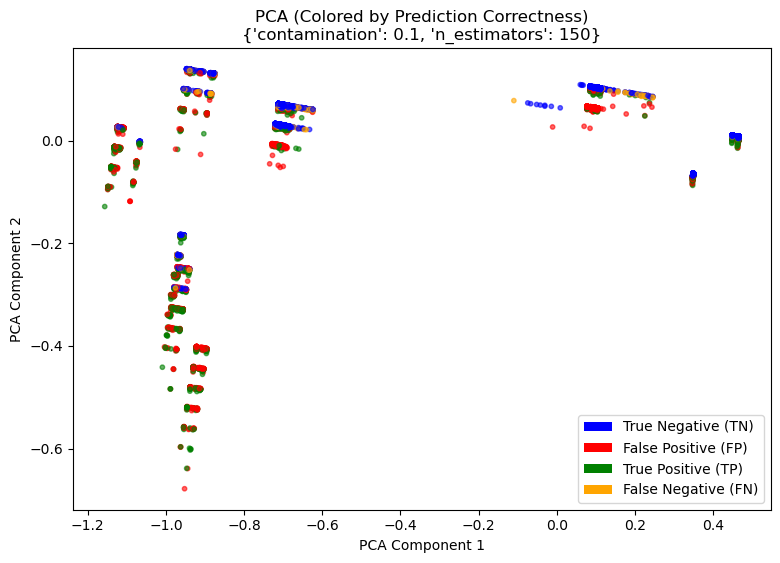

Config: {'contamination': 0.15, 'n_estimators': 150}

Accuracy:  0.8634
Precision: 0.3881
Recall:    0.5652
F1-score:  0.4602


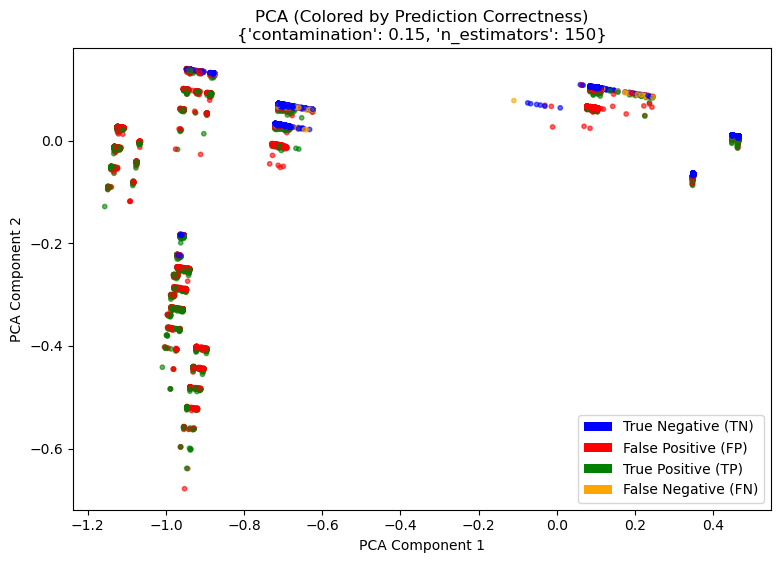

Config: {'contamination': 0.2, 'n_estimators': 150}

Accuracy:  0.8387
Precision: 0.3543
Recall:    0.6879
F1-score:  0.4677


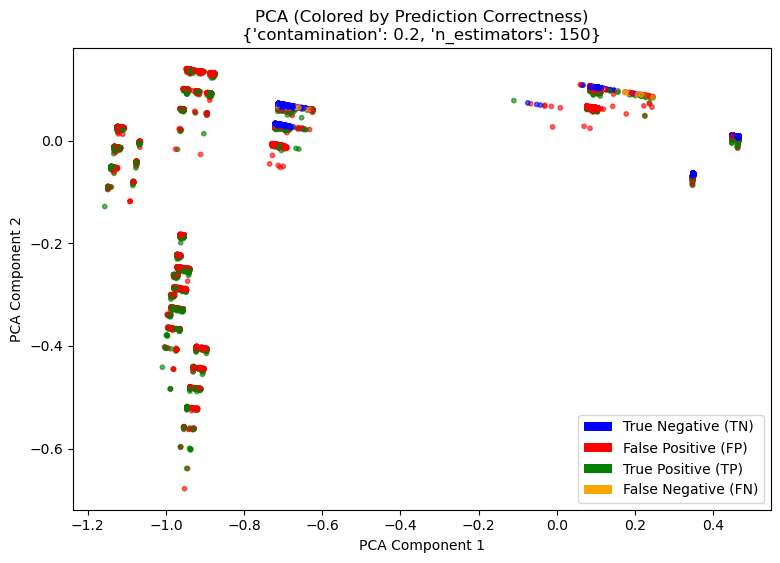

Config: {'contamination': 0.25, 'n_estimators': 150}

Accuracy:  0.7983
Precision: 0.3025
Recall:    0.7333
F1-score:  0.4283


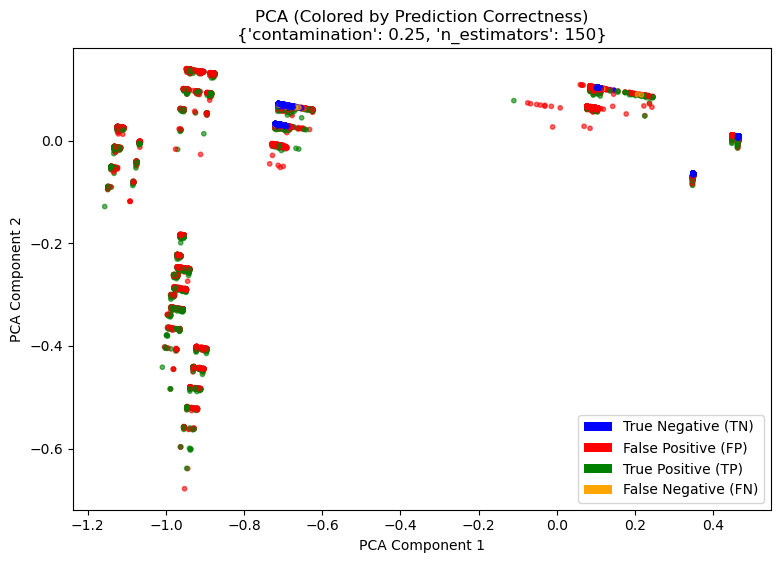

Config: {'contamination': 0.05, 'n_estimators': 200}

Accuracy:  0.8963
Precision: 0.4930
Recall:    0.2394
F1-score:  0.3223


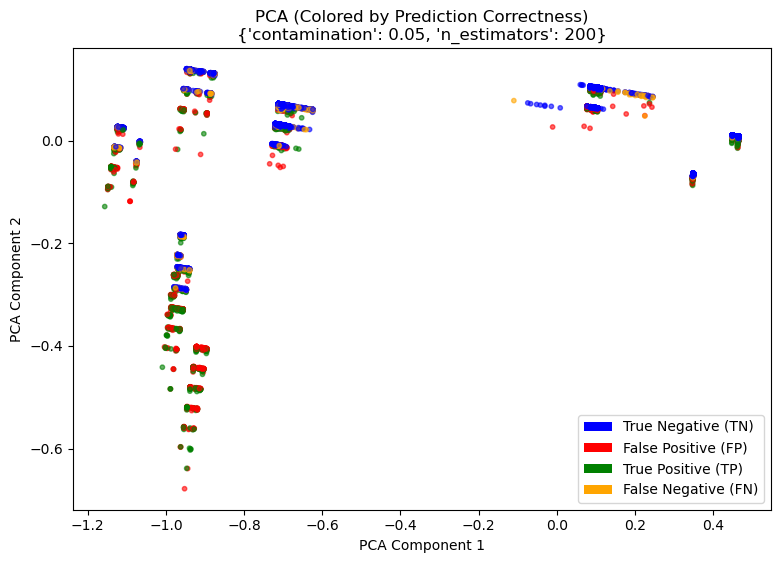

Config: {'contamination': 0.1, 'n_estimators': 200}

Accuracy:  0.8762
Precision: 0.3959
Recall:    0.3843
F1-score:  0.3900


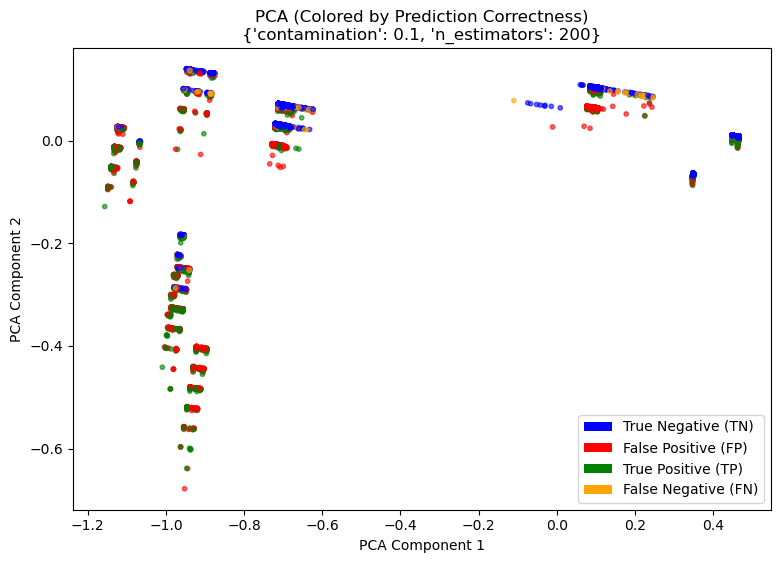

Config: {'contamination': 0.15, 'n_estimators': 200}

Accuracy:  0.8643
Precision: 0.3909
Recall:    0.5693
F1-score:  0.4636


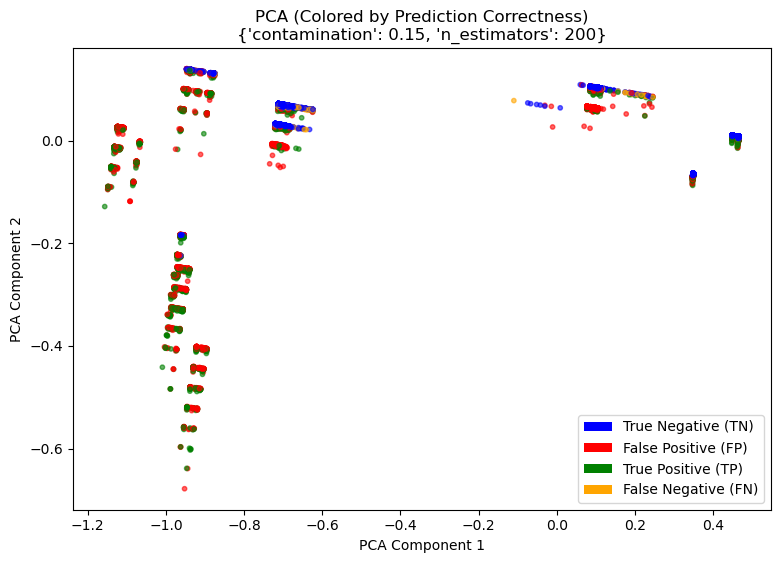

Config: {'contamination': 0.2, 'n_estimators': 200}

Accuracy:  0.8385
Precision: 0.3538
Recall:    0.6870
F1-score:  0.4671


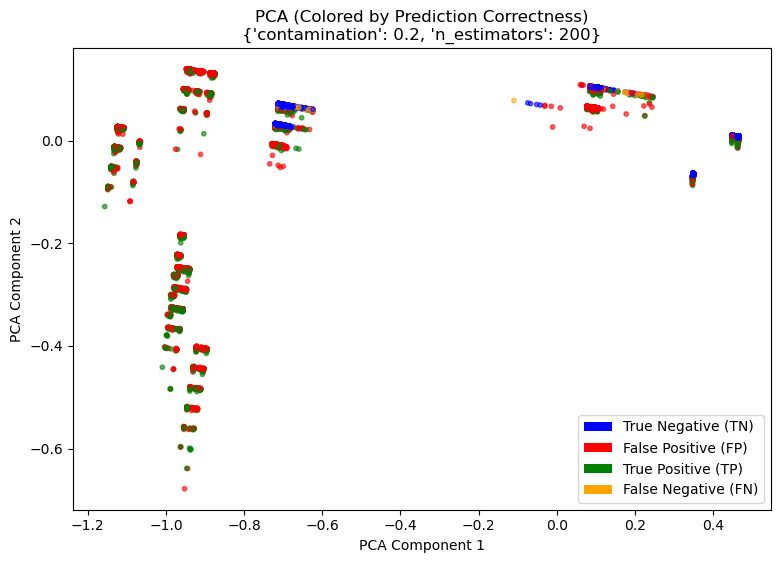

Config: {'contamination': 0.25, 'n_estimators': 200}

Accuracy:  0.7975
Precision: 0.3010
Recall:    0.7302
F1-score:  0.4263


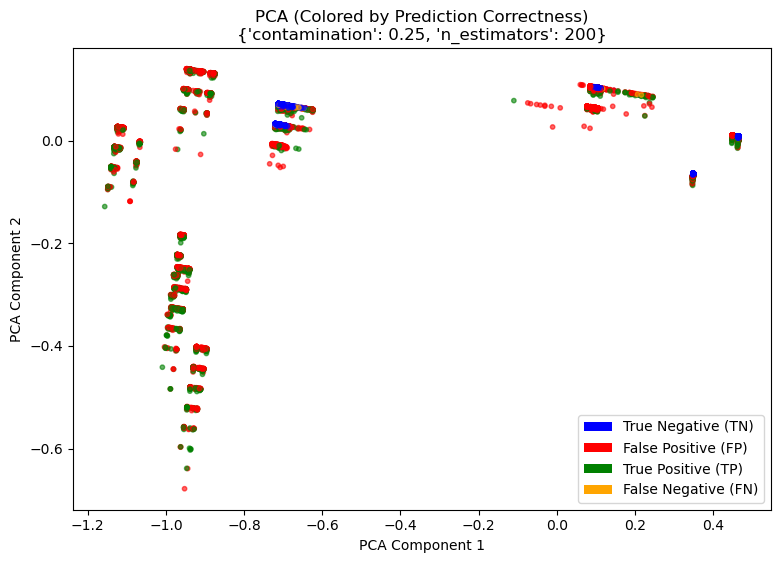

In [341]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

important_features = ['duration', 'euribor3m', 'nr.employed', 'emp.var.rate', 'previous']
X = data[important_features]
y_true = data['class']   # 0 = negative, 1 = positive

def map_iforest_pred(pred):
    # -1 → outlier (1), 1 → inlier (0)
    return (pred == -1).astype(int)

configs = [
    {"contamination": 0.05, "n_estimators": 50},
    {"contamination": 0.10, "n_estimators": 50},
    {"contamination": 0.15, "n_estimators": 50},
    {"contamination": 0.20, "n_estimators": 50},
    {"contamination": 0.25, "n_estimators": 50},
    {"contamination": 0.05, "n_estimators": 100},
    {"contamination": 0.10, "n_estimators": 100},
    {"contamination": 0.15, "n_estimators": 100},
    {"contamination": 0.20, "n_estimators": 100},
    {"contamination": 0.25, "n_estimators": 100},
    {"contamination": 0.05, "n_estimators": 150},
    {"contamination": 0.10, "n_estimators": 150},
    {"contamination": 0.15, "n_estimators": 150},
    {"contamination": 0.20, "n_estimators": 150},
    {"contamination": 0.25, "n_estimators": 150},
    {"contamination": 0.05, "n_estimators": 200},
    {"contamination": 0.10, "n_estimators": 200},
    {"contamination": 0.15, "n_estimators": 200},
    {"contamination": 0.20, "n_estimators": 200},
    {"contamination": 0.25, "n_estimators": 200},
]

def get_prediction_colors(y_true, y_pred):
    colors = []
    for true_val, pred_val in zip(y_true, y_pred):
        if pred_val == 0 and true_val == 0:
            colors.append('blue')     # True Negative
        elif pred_val == 1 and true_val == 0:
            colors.append('red')      # False Positive
        elif pred_val == 1 and true_val == 1:
            colors.append('green')    # True Positive
        else:  # pred_val == 0 and true_val == 1
            colors.append('orange')   # False Negative
    return colors

results = []

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

for cfg in configs:
    print(f"Config: {cfg}\n")

    model = IsolationForest(
        contamination=cfg["contamination"],
        n_estimators=cfg["n_estimators"],
        random_state=42
    )
    model.fit(X)

    preds_raw = model.predict(X)
    preds = map_iforest_pred(preds_raw) 

    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

    pred_colors = get_prediction_colors(y_true, preds)
    
    plt.figure(figsize=(9, 6))
    plt.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=pred_colors,
        alpha=0.6,
        s=10
    )
    plt.title(f"PCA (Colored by Prediction Correctness)\n{cfg}")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    
    legend_elements = [
        Patch(facecolor='blue', label='True Negative (TN)'),
        Patch(facecolor='red', label='False Positive (FP)'),
        Patch(facecolor='green', label='True Positive (TP)'),
        Patch(facecolor='orange', label='False Negative (FN)')
    ]
    plt.legend(handles=legend_elements)
    plt.show()
    
    model_results = {}

    model_results["IF_pred_raw"] = preds_raw
    model_results["IF_pred"] = preds
    model_results["IF_score"] = f1

    results.append({
        "config": cfg,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "model": model,
        "resdata": model_results
    })




### 4.2 Outlier Detection - Analyze Outliers

Taking the best performing Isolation Forest model from Task 4.1, enrich the data set with the predicted labels (or scores) by the model. 

Perform one or two analyses to show the characteristics of the outliers. 

In [342]:
best_result = max(results, key=lambda r: r["f1"])
best_config = best_result["config"]

print("Best Isolation Forest Model:\n")
print(best_config)
print("\nAccuracy :", best_result["accuracy"])
print("Precision:", best_result["precision"])
print("Recall   :", best_result["recall"])
print("F1-score:", best_result["f1"])

if_test_results = {
    "accuracy": best_result["accuracy"],
    "precision": best_result["precision"],
    "recall": best_result["recall"],
    "f1": best_result["f1"]
}

if_best_model = best_result["model"]
best_model_results = best_result["resdata"]

data["IF_pred_raw"] = best_model_results["IF_pred_raw"]
data["IF_pred"] = best_model_results["IF_pred"]
data["IF_score"] = best_model_results["IF_score"]

job_cols = [c for c in data.columns if c.startswith("job=")]
if job_cols:
    data["job"] = data[job_cols].idxmax(axis=1).str.replace("job=", "", regex=False)
else:
    data["job"] = np.nan

education_cols = [c for c in df.columns if c.startswith("education=")]
if education_cols:
    data["education"] = data[education_cols].idxmax(axis=1).str.replace("education=", "", regex=False)
else:
    data["education"] = np.nan

print("\nSummary statistics for OUTLIERS vs INLIERS")

outliers = data[data["IF_pred"] == 1]
inliers = data[data["IF_pred"] == 0]

print("Counts:")
print(data["IF_pred"].value_counts())
print("\nSummary (Outliers):")
print(outliers.describe().T)
print("\nSummary (Inliers):")
print(inliers.describe().T)

print("Inlier distribution - Job:")
print(inliers["job"].value_counts(normalize=True))

print("\nOutlier distribution - Job:")
print(outliers["job"].value_counts(normalize=True))

print("Inlier distribution - Education:")
print(inliers["education"].value_counts(normalize=True))

print("\nOutlier distribution - Education:")
print(outliers["education"].value_counts(normalize=True))

Best Isolation Forest Model:

{'contamination': 0.2, 'n_estimators': 150}

Accuracy : 0.8387080720613118
Precision: 0.3543169942771834
Recall   : 0.6879227053140097
F1-score: 0.46772869108227955

Summary statistics for OUTLIERS vs INLIERS
Counts:
IF_pred
0    32150
1     8038
Name: count, dtype: int64

Summary (Outliers):
                  count      mean           std       min       25%       50%  \
age              8038.0  0.300734  1.653620e-01  0.000000  0.172840  0.259259   
job=housemaid    8038.0  0.025131  1.565316e-01  0.000000  0.000000  0.000000   
job=services     8038.0  0.068052  2.518504e-01  0.000000  0.000000  0.000000   
job=admin.       8038.0  0.286638  4.522193e-01  0.000000  0.000000  0.000000   
job=blue-collar  8038.0  0.131376  3.378321e-01  0.000000  0.000000  0.000000   
...                 ...       ...           ...       ...       ...       ...   
class            8038.0  0.354317  4.783356e-01  0.000000  0.000000  0.000000   
IF_pred_raw      8038.0 -1.0

## Bonus Tasks 

We would like to challenge you with the following bonus tasks. For each task that is successfully completed, you may obtain max. 0.5 extra point. 

### Bonus Task 1

Implement another outlier detection algorithm (for example, LOF, OC-SVM, Autoencoder) or design your own outlier detection algorithm that achieves a better F1 score. 




In [343]:
# We chose OC-SVM because we wanted to use another unsupervised outlier detection method so that we would have 2 types per family to compare. 
# We knew beforehand that OC-SVM would probably not perform better than our other models, especially not better than our supervised models, but we wanted to include it for completeness.
# We also moved the cell of this code higher up the notebook so we can read the results for the table later

from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Get all data
important_features = ['duration', 'euribor3m', 'nr.employed', 'emp.var.rate', 'previous']
X_all = data[important_features]
y_all = data['class']

# because we know around 10% of the data is outlier, we can set nu to values around 0.1
nu_values = [0.075, 0.1, 0.125, 0.15]
gamma_values = [0.001, 0.01, 0.1]

results = []

# because this model is very slow to train, we will only use a sample of 5000 instances for hyperparameter tuning, 
# and then train the best model on all data and use those results for evaluation
sample_size = 5000  
indices = np.random.RandomState(42).choice(len(X_all), sample_size, replace=False)
X_sample = X_all.iloc[indices]
y_sample = y_all.iloc[indices]

for nu in nu_values:
    for gamma in gamma_values:
        print(f"\nTrying nu={nu}, gamma={gamma}")
        
        # Train One-Class SVM on all data (without labels)
        ocsvm = OneClassSVM(kernel="rbf", gamma=gamma, nu=nu)
        ocsvm.fit(X_sample)
        
        # Predict on all data: -1 = outlier, 1 = inlier
        y_pred_raw = ocsvm.predict(X_sample)
        # Map: -1 → 1 (outlier), 1 → 0 (inlier)
        y_pred = (y_pred_raw == -1).astype(int)
        
        # Evaluate against true labels
        acc = accuracy_score(y_sample, y_pred)
        prec = precision_score(y_sample, y_pred, zero_division=0)
        rec = recall_score(y_sample, y_pred, zero_division=0)
        f1 = f1_score(y_sample, y_pred, zero_division=0)
        
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1-score : {f1:.4f}")
        
        results.append({
            "nu": nu,
            "gamma": gamma,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "model": ocsvm
        })

# Find best model by F1 score
best_result = max(results, key=lambda r: r["f1"])

print("\n" + "="*50)
print("Best One-Class SVM Model on sample data:")
print(f"nu: {best_result['nu']}, gamma: {best_result['gamma']}")
print(f"\nAccuracy : {best_result['accuracy']:.4f}")
print(f"Precision: {best_result['precision']:.4f}")
print(f"Recall   : {best_result['recall']:.4f}")
print(f"F1-score : {best_result['f1']:.4f}")

# Train best model on all data
best_ocsvm = OneClassSVM(kernel="rbf", gamma=best_result["gamma"], nu=best_result["nu"])
best_ocsvm.fit(X_all)
y_all_pred_raw = best_ocsvm.predict(X_all)
y_all_pred = (y_all_pred_raw == -1).astype(int)

acc_all = accuracy_score(y_all, y_all_pred)
prec_all = precision_score(y_all, y_all_pred, zero_division=0)
rec_all = recall_score(y_all, y_all_pred, zero_division=0)
f1_all = f1_score(y_all, y_all_pred, zero_division=0)

print("\nEvaluation on ALL data with best One-Class SVM model:")
print(f"Accuracy : {acc_all:.4f}")
print(f"Precision: {prec_all:.4f}")
print(f"Recall   : {rec_all:.4f}")
print(f"F1-score : {f1_all:.4f}")

# Store results for comparison table
ocsvm_test_results = {
    "accuracy": acc_all,
    "precision": prec_all,
    "recall": rec_all,
    "f1": f1_all
}


Trying nu=0.075, gamma=0.001
Accuracy : 0.8724
Precision: 0.3182
Recall   : 0.2371
F1-score : 0.2717

Trying nu=0.075, gamma=0.01
Accuracy : 0.8724
Precision: 0.3182
Recall   : 0.2371
F1-score : 0.2717

Trying nu=0.075, gamma=0.1
Accuracy : 0.8722
Precision: 0.3173
Recall   : 0.2371
F1-score : 0.2714

Trying nu=0.1, gamma=0.001
Accuracy : 0.8638
Precision: 0.3177
Recall   : 0.3108
F1-score : 0.3142

Trying nu=0.1, gamma=0.01
Accuracy : 0.8630
Precision: 0.3174
Recall   : 0.3167
F1-score : 0.3170

Trying nu=0.1, gamma=0.1
Accuracy : 0.8626
Precision: 0.3146
Recall   : 0.3127
F1-score : 0.3137

Trying nu=0.125, gamma=0.001
Accuracy : 0.8490
Precision: 0.2982
Recall   : 0.3725
F1-score : 0.3313

Trying nu=0.125, gamma=0.01
Accuracy : 0.8510
Precision: 0.3043
Recall   : 0.3765
F1-score : 0.3366

Trying nu=0.125, gamma=0.1
Accuracy : 0.8500
Precision: 0.3019
Recall   : 0.3765
F1-score : 0.3351

Trying nu=0.15, gamma=0.001
Accuracy : 0.8268
Precision: 0.2748
Recall   : 0.4422
F1-score : 0.3

## Task 5. Report your results and discuss your findings

### 5.1 Compare the performances 

By now, you have applied three algorithms with different parameters on the data set. For each algorithm, you have create tables or figures which you can add to your report. Discuss the results and their optimal performance. 

Create an overview table or figure that show the optimal performance of each algorithm on the data set, for example see the table here below. 

Discuss your findings in the report and reflect on the following questions:
- According to the performance results, which one is the optimal model? 
- How large is the difference between the accuracy score and the F1 score for each model? What caused the difference?
- Which of performance measures (the accuracy score, recall, precision, or F1-score) would you use for comparing the model performance? Why?
- You are comparing the performance of supervised algorithms (DT and RF) with an unsupervised algorithm (Isolation Forest). Is this a fair comparison? Motivate your answer. 



| Model | Validation Accuracy  | Test Accuracy |  Validation Recall  |  Test Recall  | Validation F1 | Test F1 |... |
|------|------|------|------|------|------|------|-----|
|   Decision Tree  | | | | | | |
|   Random Forest  | | | | | | |
|   Isolation Forest        |  |  | |  | | |



In [344]:
import pandas as pd

df_data = {
    "Metric": [
        "Validation Accuracy", "Test Accuracy",
        "Validation Recall", "Test Recall",
        "Validation Precision", "Test Precision",
        "Validation F1", "Test F1"
    ],
    "Decision Tree": [
        round(dt_validation_results["accuracy"], 4),
        round(dt_test_results["accuracy"], 4),
        round(dt_validation_results["recall"], 4),
        round(dt_test_results["recall"], 4),
        round(dt_validation_results["precision"], 4),
        round(dt_test_results["precision"], 4),
        round(dt_validation_results["f1"], 4),
        round(dt_test_results["f1"], 4)
    ],
    "Random Forest": [
        round(rf_validation_results["accuracy"], 4),
        round(rf_test_results["accuracy"], 4),
        round(rf_validation_results["recall"], 4),
        round(rf_test_results["recall"], 4),
        round(rf_validation_results["precision"], 4),
        round(rf_test_results["precision"], 4),
        round(rf_validation_results["f1"], 4),
        round(rf_test_results["f1"], 4)
    ],
    "Isolation Forest": [
        "",
        round(if_test_results["accuracy"], 4),
        "",
        round(if_test_results["recall"], 4),
        "",
        round(if_test_results["precision"], 4),
        "",
        round(if_test_results["f1"], 4)
    ],
    "One-Class SVM": [
        "",
        round(ocsvm_test_results["accuracy"], 4),
        "",
        round(ocsvm_test_results["recall"], 4),
        "",
        round(ocsvm_test_results["precision"], 4),
        "",
        round(ocsvm_test_results["f1"], 4)
    ]
}

df = pd.DataFrame(df_data)
print(df.to_markdown(index=False))

| Metric               |   Decision Tree |   Random Forest | Isolation Forest   | One-Class SVM   |
|:---------------------|----------------:|----------------:|:-------------------|:----------------|
| Validation Accuracy  |          0.9132 |          0.9157 |                    |                 |
| Test Accuracy        |          0.9096 |          0.9132 | 0.8387             | 0.8385          |
| Validation Recall    |          0.5254 |          0.5139 |                    |                 |
| Test Recall          |          0.4712 |          0.4678 | 0.6879             | 0.4449          |
| Validation Precision |          0.6055 |          0.6226 |                    |                 |
| Test Precision       |          0.589  |          0.6161 | 0.3543             | 0.3053          |
| Validation F1        |          0.5612 |          0.5615 |                    |                 |
| Test F1              |          0.5235 |          0.5318 | 0.4677             | 0.3621          |


| Metric               |   Decision Tree |   Random Forest | Isolation Forest   | One-Class SVM   |
|:---------------------|----------------:|----------------:|:-------------------|:----------------|
| Validation Accuracy  |          0.9132 |          0.9181 |                    |                 |
| Test Accuracy        |          0.9096 |          0.9164 | 0.8387             | 0.8385          |
| Validation Recall    |          0.5254 |          0.5126 |                    |                 |
| Test Recall          |          0.4712 |          0.5205 | 0.6879             | 0.4449          |
| Validation Precision |          0.6055 |          0.6251 |                    |                 |
| Test Precision       |          0.589  |          0.6105 | 0.3543             | 0.3053          |
| Validation F1        |          0.5612 |          0.5631 |                    |                 |
| Test F1              |          0.5235 |          0.5619 | 0.4677             | 0.3621          |

### 5.2 Analyze and discuss the results

For each optimal model, enrich your test set by adding the predicted labels by this model to the test set. Can you think of an analysis that gives insights into when the model performs poorly?

Discuss the analysis and insights in the report


1. ERROR DISTRIBUTION ACROSS MODELS
------------------------------------------------------------
Number of models wrong per instance:
wrong_count
0    2033
1     415
2     160
3     102
4      90
Name: count, dtype: int64

Instances where ALL models correct: 2033
Instances where ALL models wrong: 90

2. SPATIAL DISTRIBUTION OF ERRORS
------------------------------------------------------------


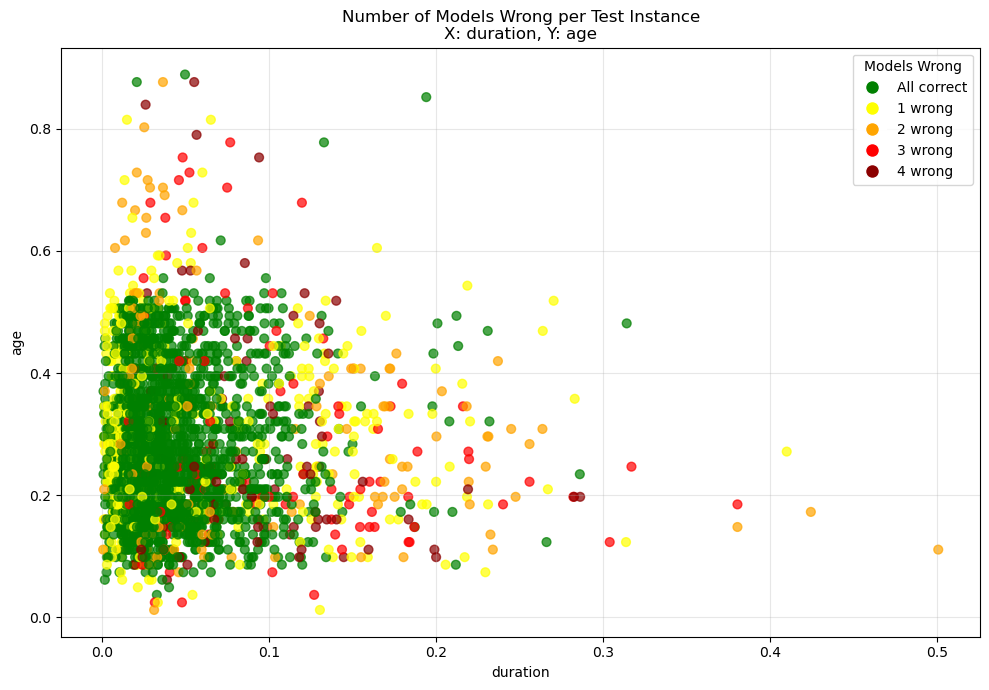

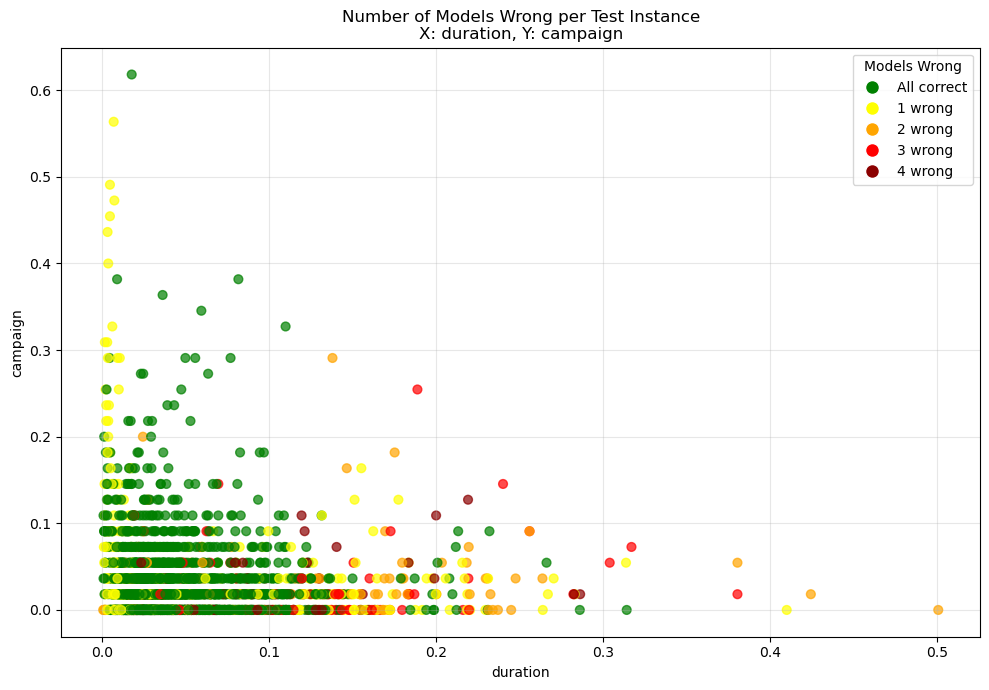

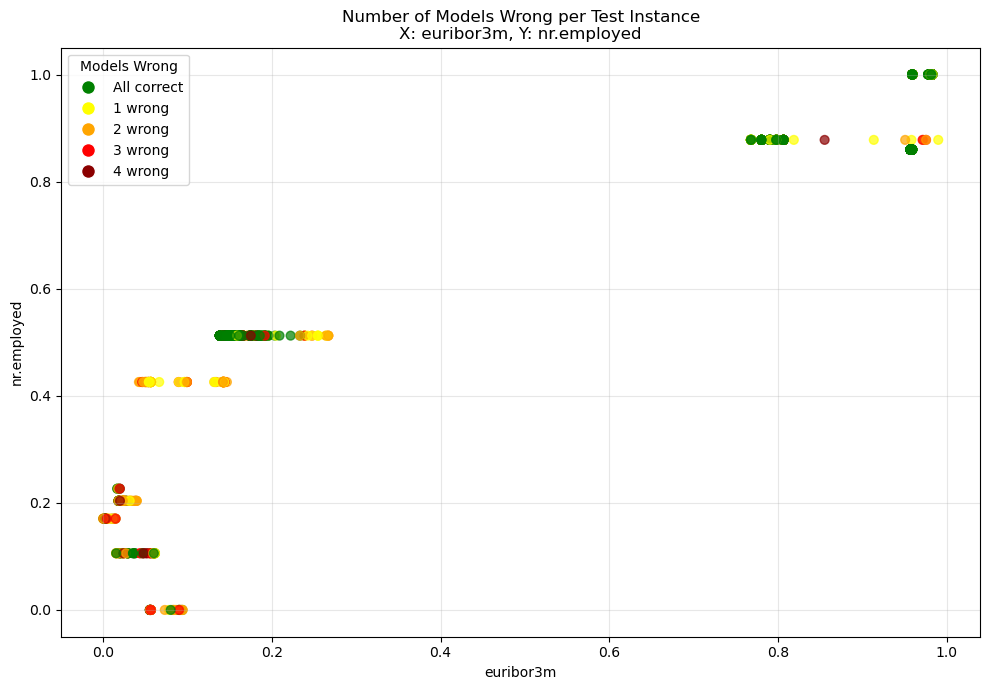

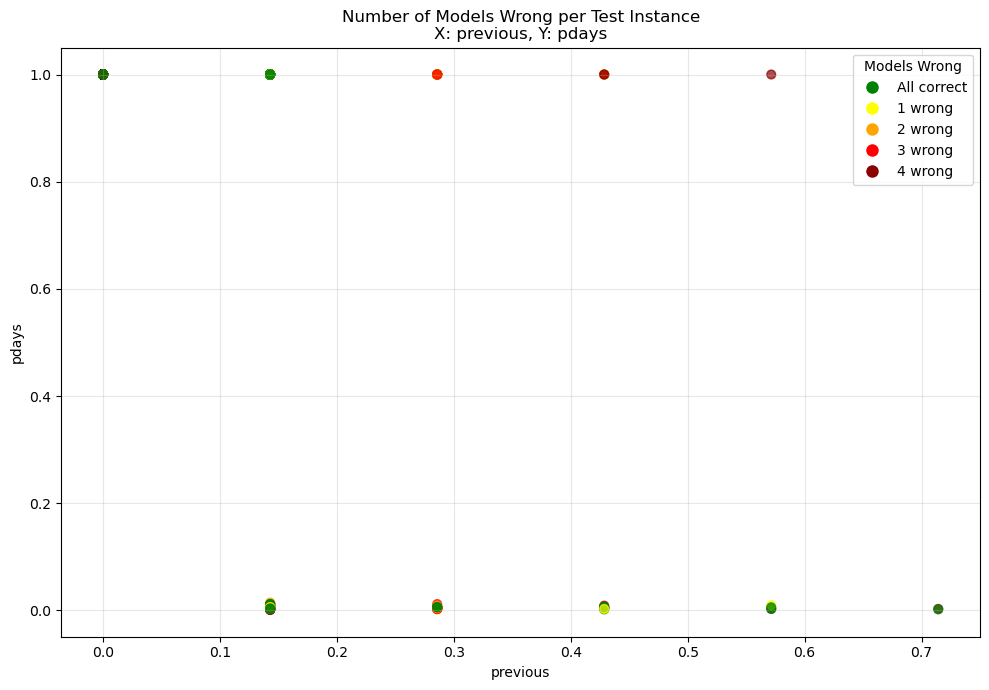


3. CONFUSION MATRICES
------------------------------------------------------------


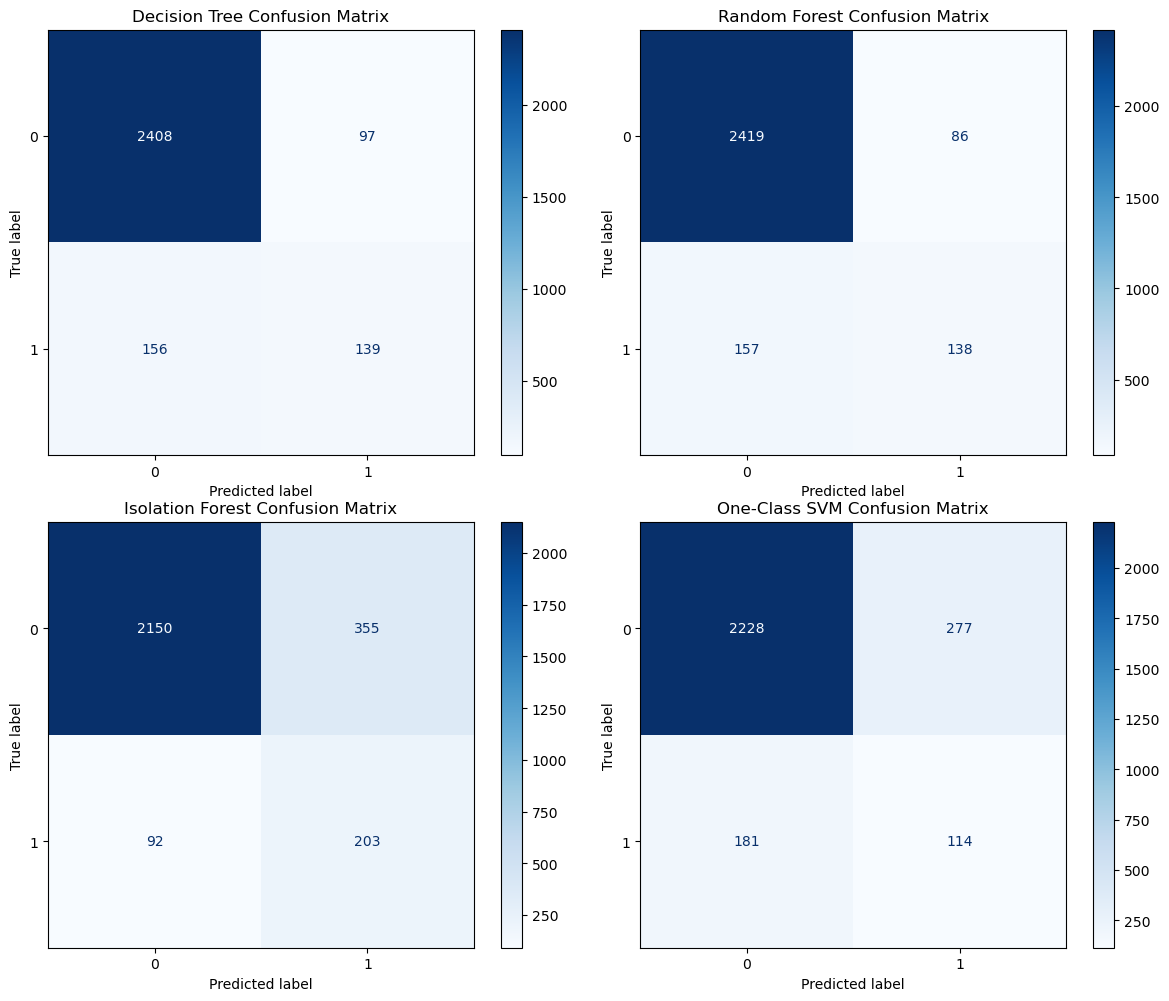


4. ERROR TYPE ANALYSIS (False Positives vs False Negatives)
------------------------------------------------------------

Decision Tree:
  True Positives:   139 | True Negatives:  2408
  False Positives:   97 | False Negatives:  156
  FP Rate: 3.87% | FN Rate: 52.88%

Random Forest:
  True Positives:   138 | True Negatives:  2419
  False Positives:   86 | False Negatives:  157
  FP Rate: 3.43% | FN Rate: 53.22%

Isolation Forest:
  True Positives:   203 | True Negatives:  2150
  False Positives:  355 | False Negatives:   92
  FP Rate: 14.17% | FN Rate: 31.19%

One-Class SVM:
  True Positives:   114 | True Negatives:  2228
  False Positives:  277 | False Negatives:  181
  FP Rate: 11.06% | FN Rate: 61.36%

5. FEATURE DISTRIBUTION: CORRECT vs INCORRECT PREDICTIONS
------------------------------------------------------------


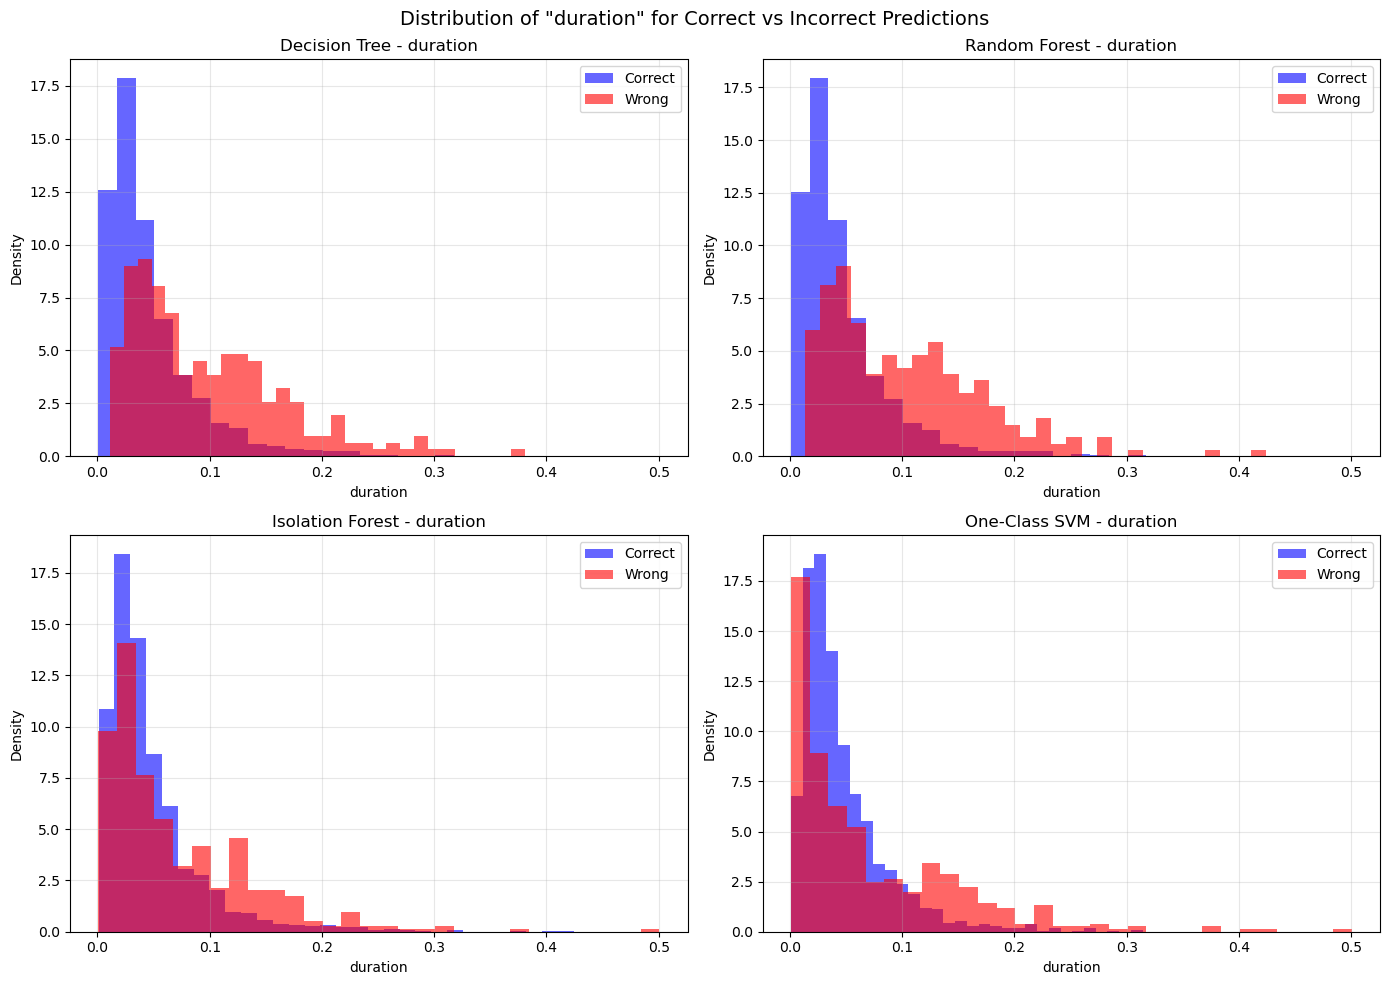

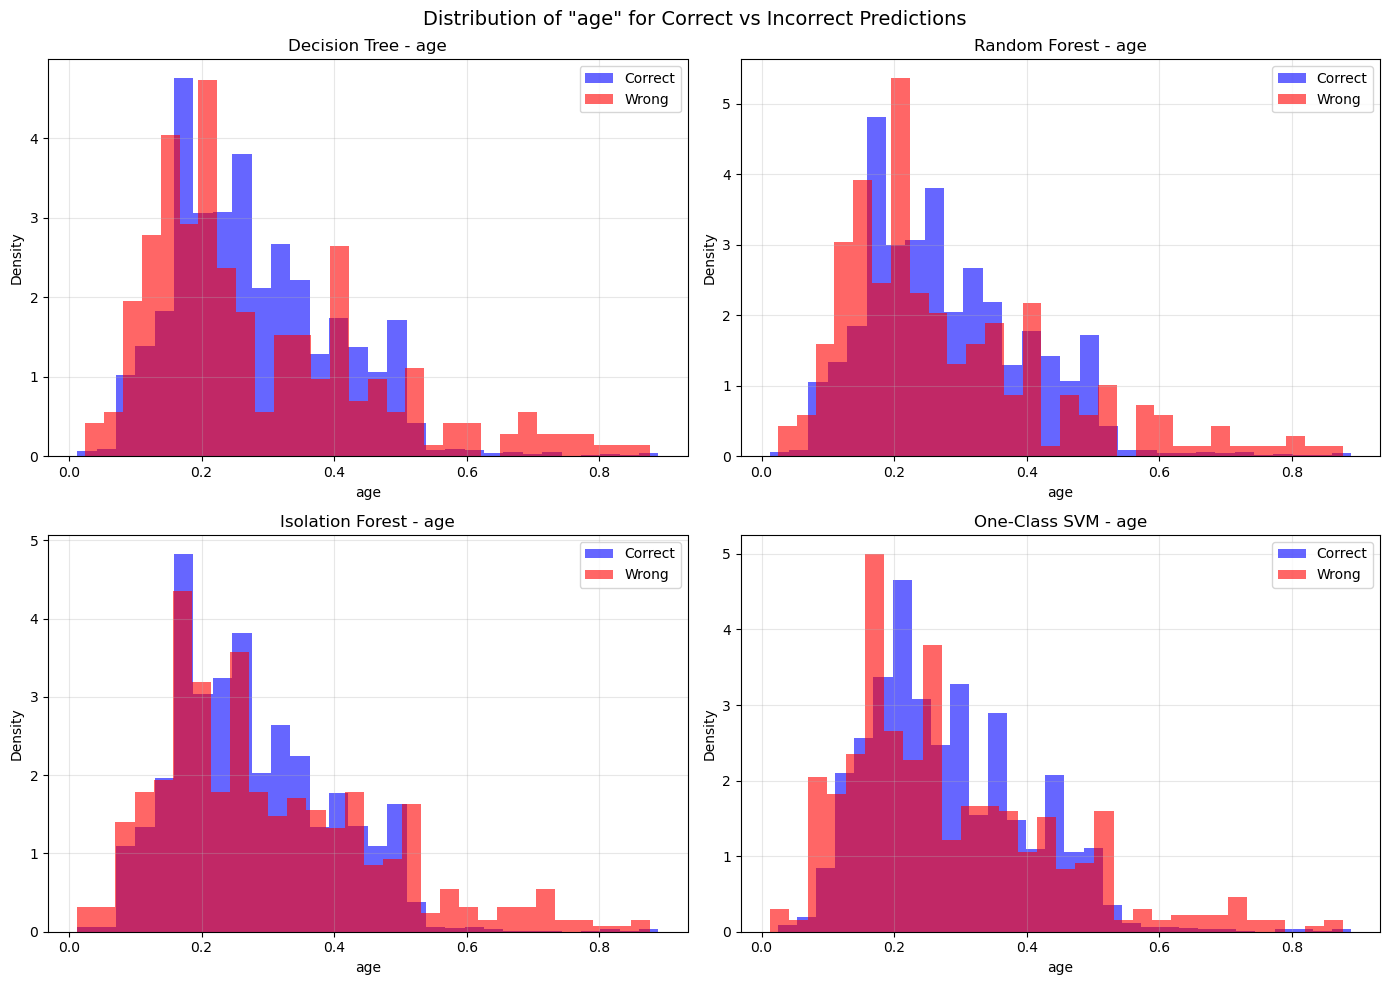

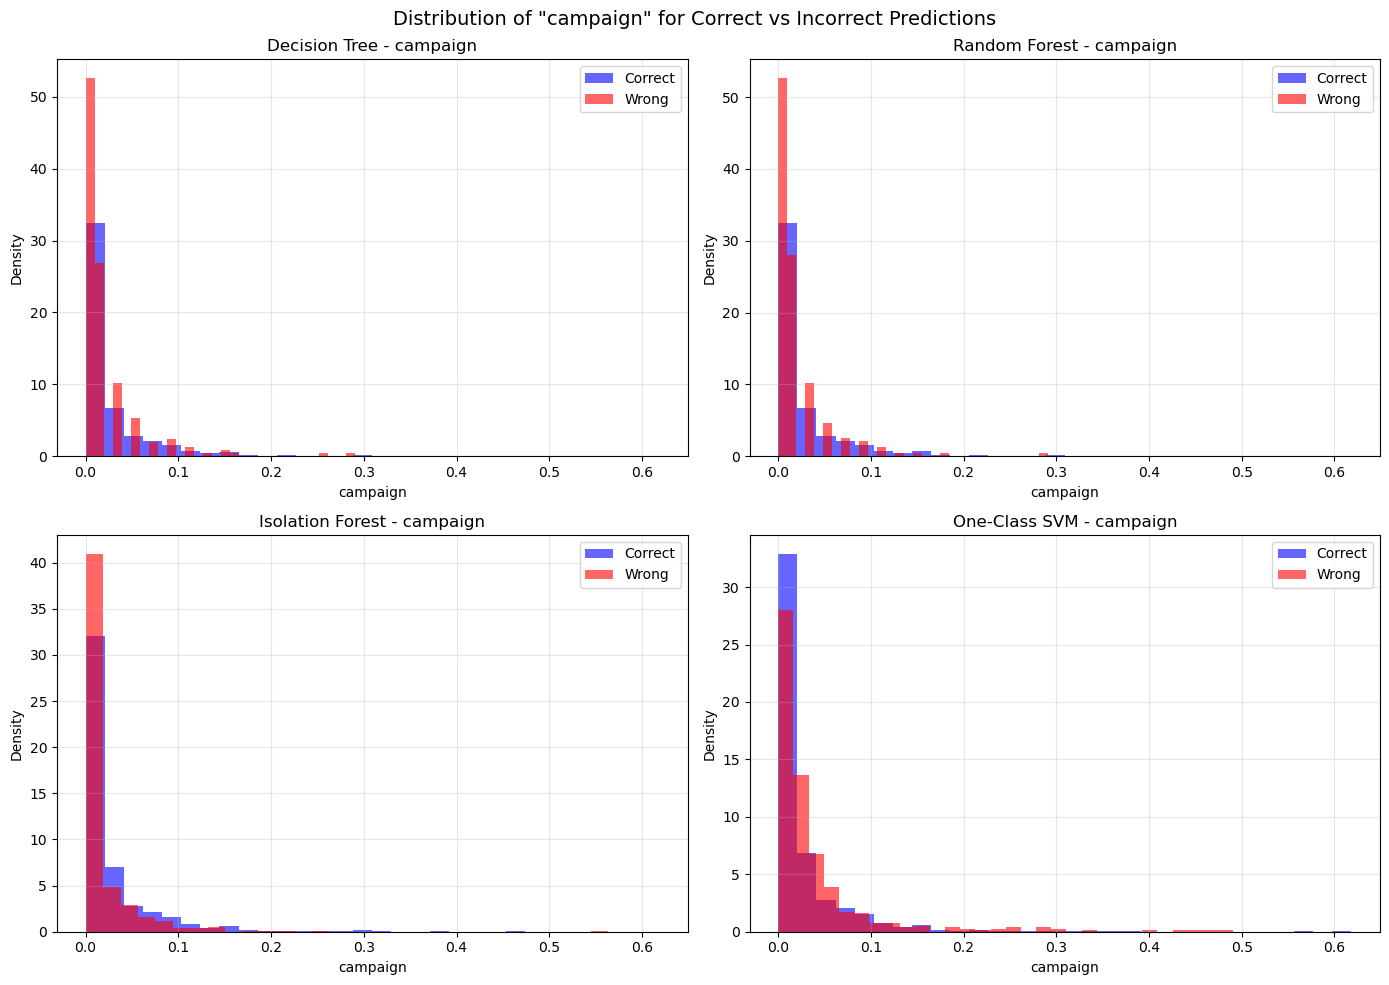

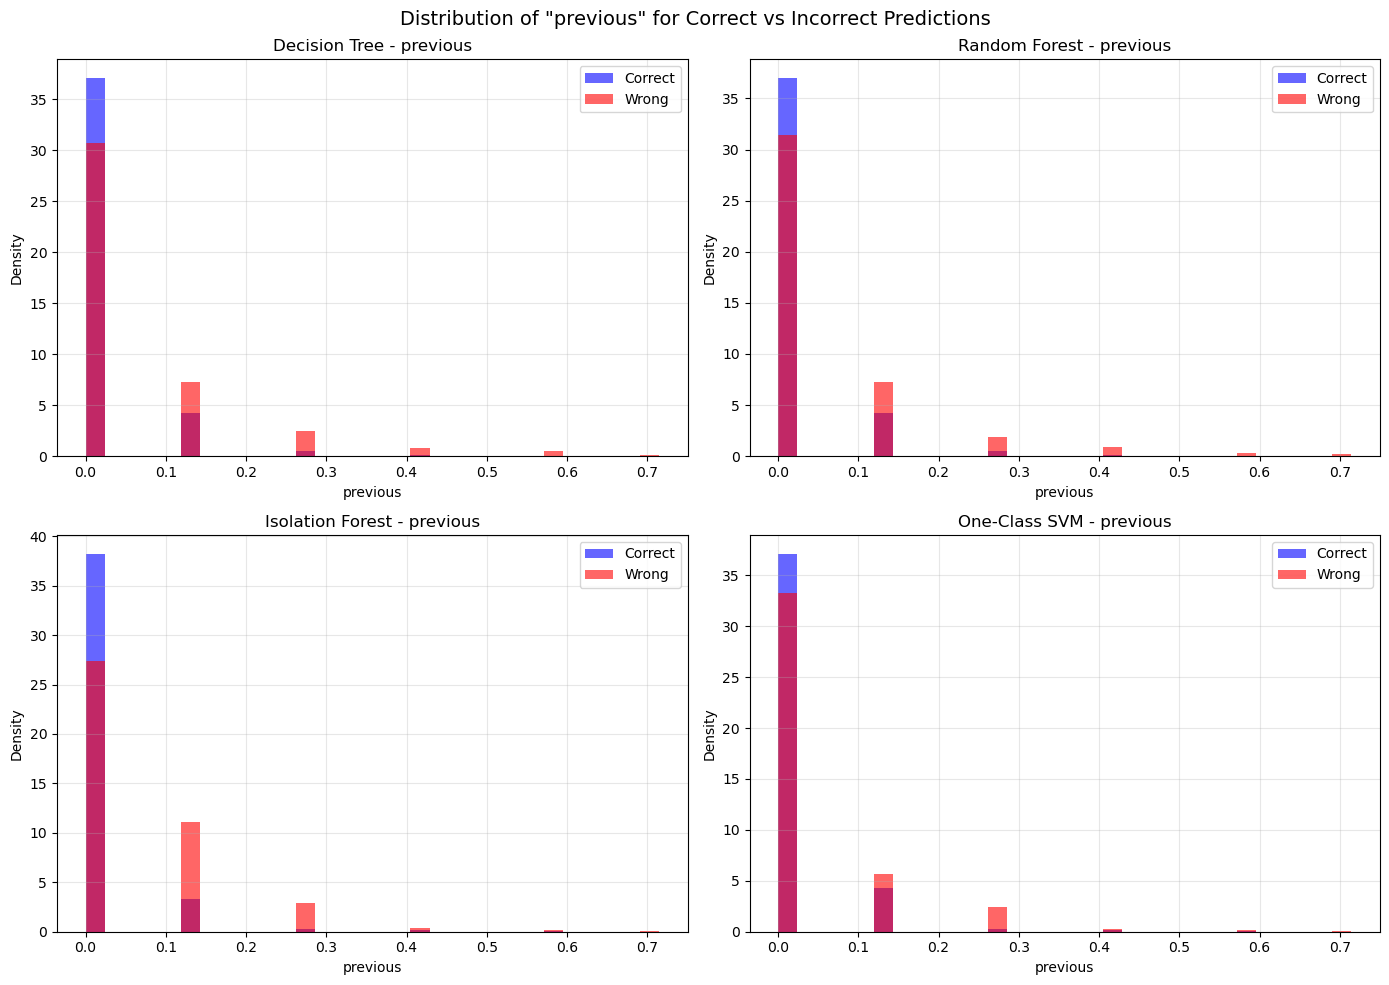

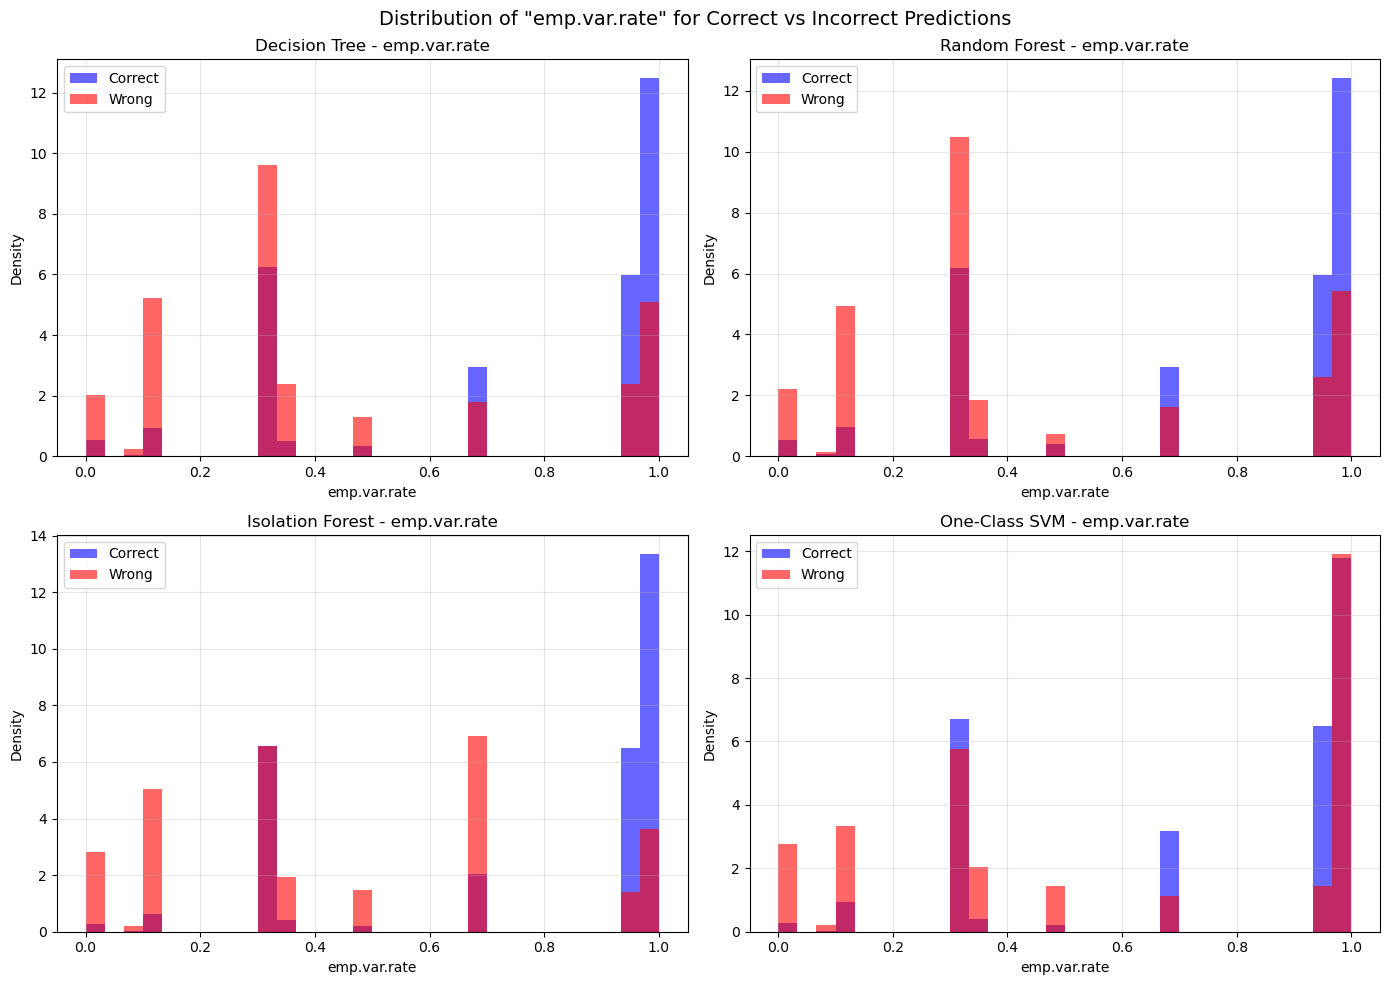

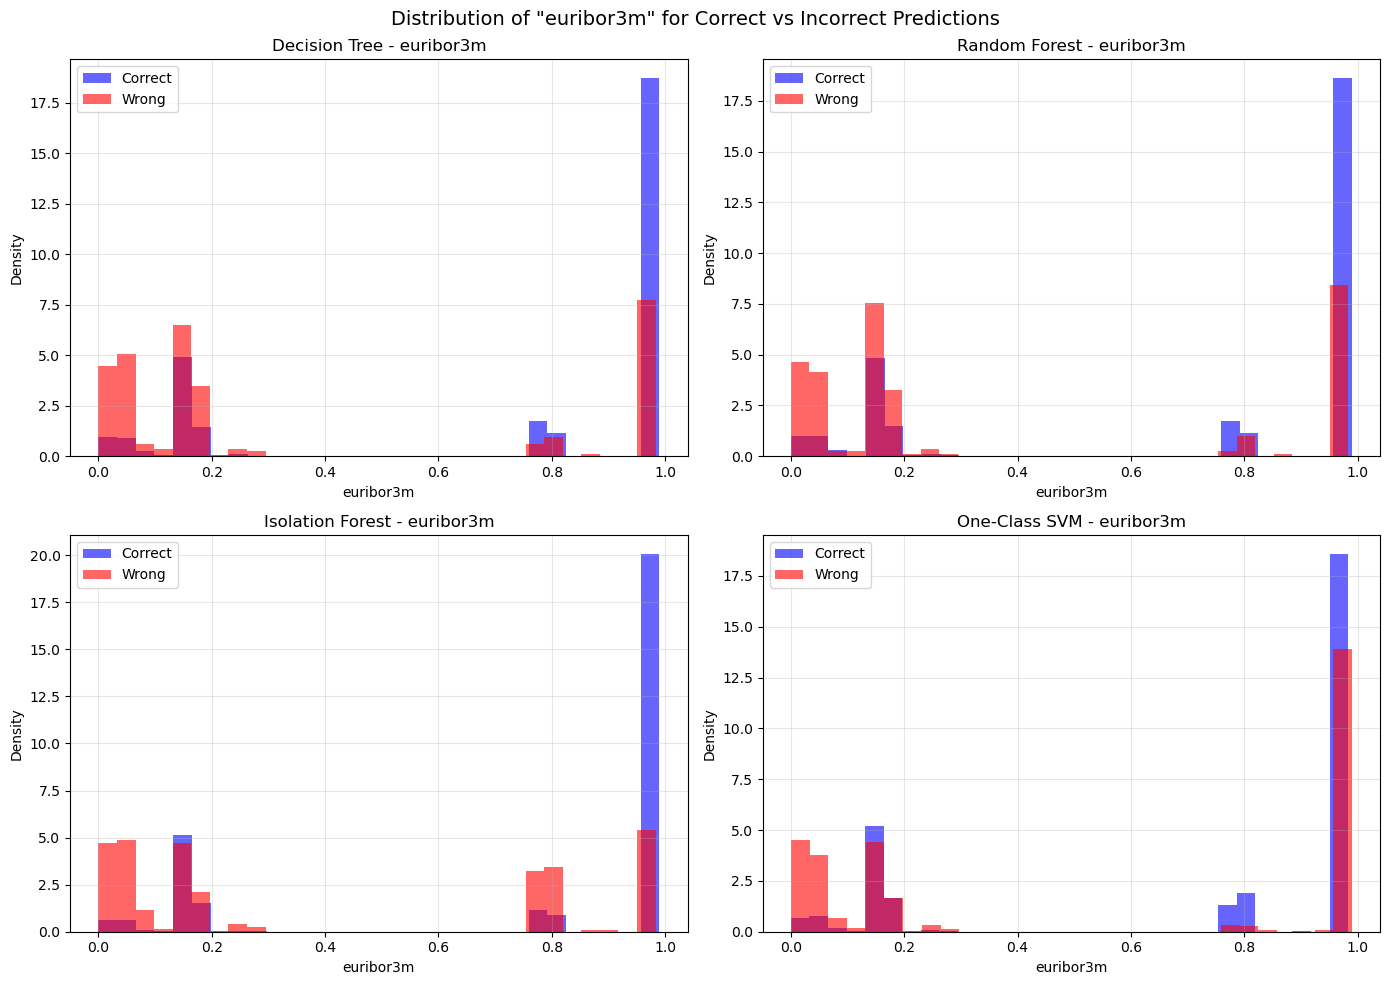


6. MODEL AGREEMENT ANALYSIS
------------------------------------------------------------
Decision Tree & Random Forest agree: 2664/2800 (95.1%)
Decision Tree & Isolation Forest agree: 2410/2800 (86.1%)
Random Forest & Isolation Forest agree: 2374/2800 (84.8%)
Isolation Forest & One-Class SVM agree: 2305/2800 (82.3%)

7. MOST CHALLANGING INSTANCES
------------------------------------------------------------
Instances where ALL 4 models failed: 90 (3.21%)

Characteristics of instances where all models fail:
  duration: mean=0.09, std=0.05
  age: mean=0.28, std=0.18
  campaign: mean=0.02, std=0.03
  previous: mean=0.07, std=0.14
  True class distribution: {1: 58, 0: 32}

Instances where ONLY Decision Tree is correct: 5

Instances where ONLY Random Forest is correct: 31

Instances where ONLY Isolation Forest is correct: 43

Instances where ONLY One-Class SVM is correct: 23


In [357]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.lines import Line2D

# Get all predictions FIRST before creating enriched dataset
# This ensures models see only the original features they were trained on

# Supervised models - predict on all features
dt_predictions = final_dt.predict(X_test)
rf_predictions = final_rf.predict(X_test)

# Unsupervised models - predict on important_features only
X_test_if_features = X_test[important_features]
if_pred_raw = if_best_model.predict(X_test_if_features)
if_predictions = map_iforest_pred(if_pred_raw)

X_test_ocsvm_features = X_test[important_features]
ocsvm_pred_raw = best_ocsvm.predict(X_test_ocsvm_features)
ocsvm_predictions = (ocsvm_pred_raw == -1).astype(int)

# Now create enriched test set with all predictions
X_test_enriched = X_test.copy()
X_test_enriched["true_label"] = y_test.values.ravel()
X_test_enriched["dt_pred"] = dt_predictions
X_test_enriched["rf_pred"] = rf_predictions
X_test_enriched["if_pred"] = if_predictions
X_test_enriched["ocsvm_pred"] = ocsvm_predictions

# Count wrong predictions per instance (0-4 models can be wrong)
X_test_enriched['wrong_count'] = (
    (X_test_enriched['dt_pred'] != X_test_enriched['true_label']).astype(int) +
    (X_test_enriched['rf_pred'] != X_test_enriched['true_label']).astype(int) +
    (X_test_enriched['if_pred'] != X_test_enriched['true_label']).astype(int) +
    (X_test_enriched['ocsvm_pred'] != X_test_enriched['true_label']).astype(int)
)

print("\n1. ERROR DISTRIBUTION ACROSS MODELS")
print("-" * 60)
print("Number of models wrong per instance:")
print(X_test_enriched['wrong_count'].value_counts().sort_index())
print(f"\nInstances where ALL models correct: {(X_test_enriched['wrong_count'] == 0).sum()}")
print(f"Instances where ALL models wrong: {(X_test_enriched['wrong_count'] == 4).sum()}")

# Visualize error patterns across feature pairs
print("\n2. SPATIAL DISTRIBUTION OF ERRORS")
print("-" * 60)

feature_pairs = [
    ('duration', 'age'),
    ('duration', 'campaign'),
    ('euribor3m', 'nr.employed'),
    ('previous', 'pdays')
]

colors = ['green', 'yellow', 'orange', 'red', 'darkred']
labels = ['All correct', '1 wrong', '2 wrong', '3 wrong', '4 wrong']

for x_feature, y_feature in feature_pairs:
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        X_test_enriched[x_feature], 
        X_test_enriched[y_feature],
        c=[colors[min(count, 4)] for count in X_test_enriched['wrong_count']],
        alpha=0.7, 
        s=40
    )
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=labels[i], 
               markerfacecolor=colors[i], markersize=10)
        for i in range(5)
    ]
    plt.legend(handles=legend_elements, title='Models Wrong', loc='best')
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f'Number of Models Wrong per Test Instance\nX: {x_feature}, Y: {y_feature}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Confusion matrices for all models
print("\n3. CONFUSION MATRICES")
print("-" * 60)

models_to_analyze = [
    ('Decision Tree', 'dt_pred'),
    ('Random Forest', 'rf_pred'),
    ('Isolation Forest', 'if_pred'),
    ('One-Class SVM', 'ocsvm_pred')
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (model_name, pred_col) in enumerate(models_to_analyze):
    cm = confusion_matrix(X_test_enriched['true_label'], X_test_enriched[pred_col])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues, ax=axes[idx])
    axes[idx].set_title(f'{model_name} Confusion Matrix')

plt.tight_layout()
plt.show()

# Error breakdown by type
print("\n4. ERROR TYPE ANALYSIS (False Positives vs False Negatives)")
print("-" * 60)

for model_name, pred_col in models_to_analyze:
    fp = ((X_test_enriched[pred_col] == 1) & (X_test_enriched['true_label'] == 0)).sum()
    fn = ((X_test_enriched[pred_col] == 0) & (X_test_enriched['true_label'] == 1)).sum()
    tp = ((X_test_enriched[pred_col] == 1) & (X_test_enriched['true_label'] == 1)).sum()
    tn = ((X_test_enriched[pred_col] == 0) & (X_test_enriched['true_label'] == 0)).sum()
    
    print(f"\n{model_name}:")
    print(f"  True Positives:  {tp:4d} | True Negatives:  {tn:4d}")
    print(f"  False Positives: {fp:4d} | False Negatives: {fn:4d}")
    print(f"  FP Rate: {fp/(fp+tn)*100:.2f}% | FN Rate: {fn/(fn+tp)*100:.2f}%")

# Feature distribution analysis for errors
print("\n5. FEATURE DISTRIBUTION: CORRECT vs INCORRECT PREDICTIONS")
print("-" * 60)

features_to_check = ['duration', 'age', 'campaign', 'previous', 'emp.var.rate', 'euribor3m']

for feature in features_to_check:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, (model_name, pred_col) in enumerate(models_to_analyze):
        correct = X_test_enriched[X_test_enriched[pred_col] == X_test_enriched['true_label']]
        wrong = X_test_enriched[X_test_enriched[pred_col] != X_test_enriched['true_label']]
        
        axes[idx].hist(correct[feature], bins=30, alpha=0.6, label='Correct', color='blue', density=True)
        axes[idx].hist(wrong[feature], bins=30, alpha=0.6, label='Wrong', color='red', density=True)
        axes[idx].set_title(f'{model_name} - {feature}')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Density')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    plt.suptitle(f'Distribution of "{feature}" for Correct vs Incorrect Predictions', fontsize=14)
    plt.tight_layout()
    plt.show()

# Model agreement analysis
print("\n6. MODEL AGREEMENT ANALYSIS")
print("-" * 60)

# Check how often models agree
dt_rf_agree = (X_test_enriched['dt_pred'] == X_test_enriched['rf_pred']).sum()
dt_if_agree = (X_test_enriched['dt_pred'] == X_test_enriched['if_pred']).sum()
rf_if_agree = (X_test_enriched['rf_pred'] == X_test_enriched['if_pred']).sum()
all_supervised_agree = ((X_test_enriched['dt_pred'] == X_test_enriched['rf_pred'])).sum()
all_unsupervised_agree = ((X_test_enriched['if_pred'] == X_test_enriched['ocsvm_pred'])).sum()

print(f"Decision Tree & Random Forest agree: {dt_rf_agree}/{len(X_test_enriched)} ({dt_rf_agree/len(X_test_enriched)*100:.1f}%)")
print(f"Decision Tree & Isolation Forest agree: {dt_if_agree}/{len(X_test_enriched)} ({dt_if_agree/len(X_test_enriched)*100:.1f}%)")
print(f"Random Forest & Isolation Forest agree: {rf_if_agree}/{len(X_test_enriched)} ({rf_if_agree/len(X_test_enriched)*100:.1f}%)")
print(f"Isolation Forest & One-Class SVM agree: {all_unsupervised_agree}/{len(X_test_enriched)} ({all_unsupervised_agree/len(X_test_enriched)*100:.1f}%)")

# Find hardest cases
print("\n7. MOST CHALLANGING INSTANCES")
print("-" * 60)

all_wrong = X_test_enriched[X_test_enriched['wrong_count'] == 4]
print(f"Instances where ALL 4 models failed: {len(all_wrong)} ({len(all_wrong)/len(X_test_enriched)*100:.2f}%)")

if len(all_wrong) > 0:
    print("\nCharacteristics of instances where all models fail:")
    for feat in ['duration', 'age', 'campaign', 'previous']:
        if feat in all_wrong.columns:
            print(f"  {feat}: mean={all_wrong[feat].mean():.2f}, std={all_wrong[feat].std():.2f}")
    print(f"  True class distribution: {all_wrong['true_label'].value_counts().to_dict()}")

# Instances where only one model is correct
for model_name, pred_col in models_to_analyze:
    only_correct = X_test_enriched[
        (X_test_enriched[pred_col] == X_test_enriched['true_label']) &
        (X_test_enriched['wrong_count'] == 3)
    ]
    if len(only_correct) > 0:
        print(f"\nInstances where ONLY {model_name} is correct: {len(only_correct)}")




### Bonus Task 2 

Implement techniques (e.g., preprocessing, feature engineering, sampling) that help improve the F1 scores of existing models


### Prediction Challenge 

- Import the independent test set without labels, apply your best performing model on this test set. 

- Enrich the test set with the predicted labels (**name this column 'predictedClass'**) 

- Export both the model as pkl file and the enriched test data set as a csv file. 

- The top three teams that have achieved the best accuracy score wins max. 0.3 bonus points.




In [ ]:
import sklearn
print(sklearn.__version__)


1.7.2
